# Benchmark: Multivariate Time-Series Fault Classification

Model selection study conducted as part of an MSc thesis at Bertelsmann Marketing Services (2025–2026).

**8 models benchmarked on 14,073 labelled industrial events using 3-fold stratified cross-validation.**

| Model | AUC | Notes |
|---|---|---|
| TST (Transformer) | 0.6742 | |
| FCN | 0.6752 | |
| ConvTimeNet | 0.6968 ± 0.0131 | |
| LSTM-FCN | 0.7013 | |
| InceptionTime | 0.7270 | |
| TapNet (TS only) | 0.7820 ± 0.0129 | |
| XGBoost (TS only) | 0.7895 ± 0.0026 | Ablation — no metadata |
| TapNet + metadata | 0.8100 ± 0.0072 | +0.028 from metadata |
| **XGBoost + metadata** | **0.8595 ± 0.0009** | **Best — +0.070 from metadata** |

**Key finding: metadata fusion adds +0.070 AUC to XGBoost and +0.028 to TapNet — consistent across both model families.**

The production pipeline in `src/` uses XGBoost + metadata (fold 1, AUC 0.8606).

> **Data note:** Cell outputs are from runs on proprietary industrial sensor data.
> All event IDs, file paths, and internal machine identifiers have been removed.
> Results are reported as aggregate metrics only.


In [ ]:
# ============================================================
# CELL 1: Imports + Configuration
# ============================================================

# -------------------------
# Standard libraries
# -------------------------
import os
import re
import json
import zipfile
import pickle
import random

# -------------------------
# Data handling
# -------------------------
import numpy as np
import pandas as pd

# -------------------------
# Progress / utils
# -------------------------
from tqdm import tqdm
from collections import Counter

# -------------------------
# ML utilities
# -------------------------
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -------------------------
# Paths 
# -------------------------
DATA_DIR = r"The path to data"

# -------------------------
# Core preprocessing params
# -------------------------
TIMESTEPS = 300
NUM_FEATURES_PER_CAM = 5   # [no_defect, defect, rollenwechsel, kantenfehler, tear]
NUM_CAMERAS = 2

MIN_VALID_FRAMES = 10

# -------------------------
# Score order (FIXED)
# -------------------------
SCORE_KEYS = [
    "no_defect",
    "defect",
    "rollenwechsel",
    "Kantenfehler",
    "tear"
]

# -------------------------
# Output paths (for reproducibility)
# -------------------------
OUTPUT_DIR = "./processed_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_SEQ_PATH = os.path.join(OUTPUT_DIR, "X_seq.npy")
Y_PATH = os.path.join(OUTPUT_DIR, "y.npy")
EVENT_DATA_PATH = os.path.join(OUTPUT_DIR, "event_data.pkl")

# -------------------------
# Print config summary
# -------------------------
print("Configuration:")
print(f"DATA_DIR: {DATA_DIR}")
print(f"TIMESTEPS: {TIMESTEPS}")
print(f"MIN_VALID_FRAMES: {MIN_VALID_FRAMES}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

In [4]:
# ============================================================
# CELL 2: Helper Functions for Preprocessing
# ============================================================

# -------------------------
# Check if a frame is valid
# -------------------------
def is_valid_frame(frame):
    scores = frame.get("scores")
    if not isinstance(scores, dict):
        return False
    return any(v > 0 for v in scores.values())


# -------------------------
# Extract score vector from frame
# -------------------------
def extract_score_vector(frame):
    scores = frame.get("scores", {})
    return [float(scores.get(k, 0.0)) for k in SCORE_KEYS]


# -------------------------
# Get valid cameras from event
# -------------------------
def get_valid_cameras(videos):
    valid_cams = []

    for v in videos:
        frames = v.get("frames", [])
        if not isinstance(frames, list) or len(frames) == 0:
            continue

        usable_frames = [fr for fr in frames if is_valid_frame(fr)]

        if len(usable_frames) >= MIN_VALID_FRAMES:
            valid_cams.append(usable_frames)

    return valid_cams


# -------------------------
# Extract 300-frame window aligned to tear peak
# -------------------------
def extract_camera_window(frames):
    """
    Input:
        frames: list of valid frames
    Output:
        np.array shape (300, 5)
        valid_length (before padding)
    """

    # get tear scores
    tear_scores = [
        fr.get("scores", {}).get("tear", 0.0)
        for fr in frames
    ]

    if len(tear_scores) == 0:
        return None, 0

    # find tear peak
    tear_idx = int(np.argmax(tear_scores))

    # get frames up to peak
    seq = frames[:tear_idx + 1]

    # convert to score vectors
    seq_vectors = [extract_score_vector(fr) for fr in seq]

    valid_length = len(seq_vectors)

    # truncate if longer than 300
    if valid_length > TIMESTEPS:
        seq_vectors = seq_vectors[-TIMESTEPS:]
        valid_length = TIMESTEPS

    # left pad if shorter
    if valid_length < TIMESTEPS:
        pad_len = TIMESTEPS - valid_length
        padding = [[0.0] * NUM_FEATURES_PER_CAM for _ in range(pad_len)]
        seq_vectors = padding + seq_vectors

    return np.array(seq_vectors, dtype=np.float32), valid_length


# -------------------------
# Build full event sequence (2 cameras)
# -------------------------
def build_event_sequence(valid_cams):
    """
    Input:
        valid_cams: list of camera frame lists
    Output:
        X_seq_event: (300, 10)
        meta_info: dict
    """

    cam_sequences = []
    valid_lengths = []

    # process up to 2 cameras
    for i in range(min(len(valid_cams), 2)):
        seq, valid_len = extract_camera_window(valid_cams[i])

        if seq is None:
            continue

        cam_sequences.append(seq)
        valid_lengths.append(valid_len)

    # handle cases
    if len(cam_sequences) == 2:
        camera2_present = 1

    elif len(cam_sequences) == 1:
        # pad second camera
        zero_cam = np.zeros((TIMESTEPS, NUM_FEATURES_PER_CAM), dtype=np.float32)
        cam_sequences.append(zero_cam)
        valid_lengths.append(0)
        camera2_present = 0

    else:
        return None, None  # drop event

    # concatenate along feature dimension
    X_seq_event = np.concatenate(cam_sequences, axis=1)  # (300,10)

    # meta info for XGBoost / hybrid
    meta_info = {
        "valid_length_cam1": valid_lengths[0],
        "valid_length_cam2": valid_lengths[1],
        "padding_fraction_cam1": (TIMESTEPS - valid_lengths[0]) / TIMESTEPS,
        "padding_fraction_cam2": (TIMESTEPS - valid_lengths[1]) / TIMESTEPS,
        "camera2_present": camera2_present
    }

    return X_seq_event, meta_info


# -------------------------
# Parse numeric field (with units)
# -------------------------
def parse_numeric(value):
    if value is None:
        return np.nan

    if isinstance(value, (int, float)):
        return float(value)

    try:
        # extract number from string
        match = re.search(r"[-+]?\d*\.?\d+", str(value))
        if match:
            return float(match.group())
    except:
        pass

    return np.nan


# -------------------------
# Parse metadata from event
# -------------------------
def parse_metadata(ev):
    return {
        "speed": parse_numeric(ev.get("speed")),
        "grammage_weight": parse_numeric(ev.get("grammage_weight")),
        "web_width": parse_numeric(ev.get("web_width")),
        "pap_len": parse_numeric(ev.get("pap_len")),
        "detector": parse_numeric(ev.get("detector")),

        "printer": ev.get("printer"),
        "grade": ev.get("grade"),
        "paper_supplier": ev.get("paper_supplier"),

        "date_time_str": ev.get("date_time_str")
    }

In [5]:
# ============================================================
# CELL 3: Full Dataset Construction
# ============================================================

def read_labels_from_zip(zip_path):
    labels = {}

    with zipfile.ZipFile(zip_path, "r") as z:
        label_files = [n for n in z.namelist() if n.lower().endswith("labels.txt")]

        if not label_files:
            return labels

        with z.open(label_files[0]) as f:
            lines = f.read().decode("utf-8", errors="ignore").splitlines()

        for line in lines:
            line = line.strip()
            if not line:
                continue

            parts = re.split(r"[;,:\s]+", line)

            if len(parts) >= 2 and parts[-1] in ["0", "1"]:
                event_id = parts[0].replace("_event.json", "")
                labels[event_id] = int(parts[-1])

    return labels


def load_full_dataset():
    X_seq_list = []
    y_list = []
    event_data = []

    all_month_zips = [
        os.path.join(DATA_DIR, f)
        for f in os.listdir(DATA_DIR)
        if f.lower().endswith("_events.zip")
    ]

    total_events = 0
    dropped_no_camera = 0
    dropped_no_label = 0

    for zip_path in sorted(all_month_zips):
        print(f"\nProcessing: {os.path.basename(zip_path)}")

        labels = read_labels_from_zip(zip_path)

        with zipfile.ZipFile(zip_path, "r") as z:
            json_files = [n for n in z.namelist() if n.endswith("_event.json")]

            for jf in tqdm(json_files):
                total_events += 1

                try:
                    event_id = jf.split("/")[-1].replace("_event.json", "")

                    if event_id not in labels:
                        dropped_no_label += 1
                        continue

                    with z.open(jf) as f:
                        ev = json.load(f)

                    videos = ev.get("videos", [])

                    # Step 1: get valid cameras
                    valid_cams = get_valid_cameras(videos)

                    if len(valid_cams) == 0:
                        dropped_no_camera += 1
                        continue

                    # Step 2: build sequence
                    X_seq_event, cam_meta = build_event_sequence(valid_cams)

                    if X_seq_event is None:
                        dropped_no_camera += 1
                        continue

                    # Step 3: parse metadata
                    meta = parse_metadata(ev)

                    # Step 4: store
                    X_seq_list.append(X_seq_event)
                    y_list.append(labels[event_id])

                    event_data.append({
                        "event_id": event_id,
                        "label": labels[event_id],
                        "cam_meta": cam_meta,
                        "metadata": meta
                    })

                except Exception as e:
                    print(f"Error processing {jf}: {e}")

    # convert to arrays
    X_seq = np.array(X_seq_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)

    print("\n" + "="*60)
    print("DATASET SUMMARY")
    print("="*60)
    print(f"Total events processed: {total_events}")
    print(f"Final dataset size: {X_seq.shape}")
    print(f"Dropped (no label): {dropped_no_label}")
    print(f"Dropped (no camera): {dropped_no_camera}")
    print(f"Class distribution: {np.bincount(y)}")

    return X_seq, y, event_data


# -------------------------
# RUN PREPROCESSING
# -------------------------
X_seq, y, event_data = load_full_dataset()

# -------------------------
# SAVE FOR REPRODUCIBILITY
# -------------------------
np.save(X_SEQ_PATH, X_seq)
np.save(Y_PATH, y)

with open(EVENT_DATA_PATH, "wb") as f:
    pickle.dump(event_data, f)

print("\nSaved:")
print(f"X_seq → {X_SEQ_PATH}")
print(f"y → {Y_PATH}")
print(f"event_data → {EVENT_DATA_PATH}")


Processing: 202107_events.zip


100%|██████████| 121/121 [00:02<00:00, 48.67it/s]



Processing: 202108_events.zip


100%|██████████| 127/127 [00:02<00:00, 42.37it/s]



Processing: 202109_events.zip


...


Processing: 202411_events.zip


100%|██████████| 497/497 [00:15<00:00, 33.00it/s]



Processing: 202412_events.zip


100%|██████████| 408/408 [00:13<00:00, 31.02it/s]



DATASET SUMMARY
Total events processed: 14083
Final dataset size: (14073, 300, 10)
Dropped (no label): 0
Dropped (no camera): 10
Class distribution: [11822  2251]

Saved:
X_seq → ./processed_data\X_seq.npy
y → ./processed_data\y.npy
event_data → ./processed_data\event_data.pkl


In [ ]:
# ============================================================
# CELL 4: Cross-Validation + Scaling (Shared for ALL DL models)
# ============================================================

# -------------------------
# Create CV splits
# -------------------------
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Store all folds for reuse
cv_folds = []

print("Preparing cross-validation folds...")

for fold_idx, (train_pool_idx, test_idx) in enumerate(skf.split(X_seq, y), start=1):

    print("\n" + "="*60)
    print(f"FOLD {fold_idx}")
    print("="*60)

    # -------------------------
    # Split train pool > train + validation
    # -------------------------
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

    X_pool, y_pool = X_seq[train_pool_idx], y[train_pool_idx]

    train_rel_idx, val_rel_idx = next(sss.split(X_pool, y_pool))

    train_idx = train_pool_idx[train_rel_idx]
    val_idx   = train_pool_idx[val_rel_idx]

    # -------------------------
    # Extract splits
    # -------------------------
    X_train = X_seq[train_idx]
    X_val   = X_seq[val_idx]
    X_test  = X_seq[test_idx]

    y_train = y[train_idx]
    y_val   = y[val_idx]
    y_test  = y[test_idx]

    print(f"TRAIN: {X_train.shape} | counts: {np.bincount(y_train)}")
    print(f"VAL  : {X_val.shape}   | counts: {np.bincount(y_val)}")
    print(f"TEST : {X_test.shape}  | counts: {np.bincount(y_test)}")

    # -------------------------
    # Scaling
    # -------------------------
    scaler = StandardScaler()

    # flatten: (N, T, C) → (N*T, C)
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_val_flat   = X_val.reshape(-1, X_val.shape[-1])
    X_test_flat  = X_test.reshape(-1, X_test.shape[-1])

    # fit ONLY on training data
    scaler.fit(X_train_flat)

    # transform
    X_train_scaled = scaler.transform(X_train_flat).reshape(X_train.shape)
    X_val_scaled   = scaler.transform(X_val_flat).reshape(X_val.shape)
    X_test_scaled  = scaler.transform(X_test_flat).reshape(X_test.shape)

    # -------------------------
    # Store fold
    # -------------------------
    cv_folds.append({
        "fold": fold_idx,

        "X_train": X_train_scaled,
        "X_val": X_val_scaled,
        "X_test": X_test_scaled,

        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,

        "scaler": scaler
    })

print("\nAll folds prepared successfully.")

Preparing cross-validation folds...

FOLD 1
TRAIN: (7505, 300, 10) | counts: [6304 1201]
VAL  : (1877, 300, 10)   | counts: [1577  300]
TEST : (4691, 300, 10)  | counts: [3941  750]

FOLD 2
TRAIN: (7505, 300, 10) | counts: [6304 1201]
VAL  : (1877, 300, 10)   | counts: [1577  300]
TEST : (4691, 300, 10)  | counts: [3941  750]

FOLD 3
TRAIN: (7505, 300, 10) | counts: [6305 1200]
VAL  : (1877, 300, 10)   | counts: [1577  300]
TEST : (4691, 300, 10)  | counts: [3940  751]

All folds prepared successfully.


In [ ]:
# ============================================================
# CNN FCN CLASSIFIER 
# ============================================================

from sktime.classification.deep_learning.fcn import FCNClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, log_loss
import numpy as np
import os
import pickle
import tensorflow as tf
import matplotlib.pyplot as plt


# -------------------------
# Helper: convert shape
# -------------------------
def to_sktime_format(X):
    return np.transpose(X, (0, 2, 1)).astype(np.float32)


# -------------------------
# Threshold tuning
# -------------------------
def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 91)

    best_thr = 0.5
    best_f1 = -1

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        if cm.shape != (2, 2):
            continue

        tn, fp, fn, tp = cm.ravel()

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr


# -------------------------
# Output dirs
# -------------------------
PRED_DIR = os.path.join(OUTPUT_DIR, "cnn_predictions")
MODEL_DIR = os.path.join(OUTPUT_DIR, "cnn_trained_models")

os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


cnn_results = []

# ============================================================
# RUN CV
# ============================================================
for fold_data in cv_folds:

    fold_idx = fold_data["fold"]

    print("\n" + "="*60)
    print(f"FOLD {fold_idx} - CNN (FCN)")
    print("="*60)

    # -------------------------
    # Data
    # -------------------------
    X_train = to_sktime_format(fold_data["X_train"])
    X_val   = to_sktime_format(fold_data["X_val"])
    X_test  = to_sktime_format(fold_data["X_test"])

    y_train = fold_data["y_train"]
    y_val   = fold_data["y_val"]
    y_test  = fold_data["y_test"]

    # -------------------------
    # Model
    # -------------------------
    model = FCNClassifier(
        n_epochs=30,
        batch_size=64,
        verbose=True,
        random_state=SEED
    )

    # -------------------------
    # Train
    # -------------------------
    model.fit(X_train, y_train)

    # -------------------------
    # Plot training loss
    # -------------------------
    if hasattr(model, "history_") and "loss" in model.history_:
        plt.figure()
        plt.plot(model.history_["loss"], label="train_loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"CNN Training Loss - Fold {fold_idx}")
        plt.legend()
        plt.show()

    # -------------------------
    # Predictions
    # -------------------------
    p_val = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    # -------------------------
    # AUC
    # -------------------------
    auc = roc_auc_score(y_test, p_test)
    print(f"AUC: {auc:.4f}")

    # -------------------------
    # Test Loss
    # -------------------------
    test_loss = log_loss(y_test, p_test)
    print(f"Test Log Loss: {test_loss:.4f}")

    # -------------------------
    # Threshold tuning
    # -------------------------
    best_thr = find_best_threshold(y_val, p_val)
    print(f"Best Threshold: {best_thr:.3f}")

    # -------------------------
    # Apply threshold
    # -------------------------
    y_pred_test = (p_test >= best_thr).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    acc = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    fpr = fp / (fp + tn + 1e-12)

    report_str = classification_report(
        y_test,
        y_pred_test,
        target_names=["machine_problem", "paper_problem"],
        digits=3,
        zero_division=0
    )

    print("\nConfusion Matrix:")
    print(cm)

    print(f"\nAccuracy: {acc:.4f}")
    print(f"FPR: {fpr:.4f}")

    print("\nClassification Report:")
    print(report_str)

    # -------------------------
    # SAVE PREDICTIONS + METRICS
    # -------------------------
    pred_path = os.path.join(PRED_DIR, f"cnn_fold_{fold_idx}.pkl")

    with open(pred_path, "wb") as f:
        pickle.dump({
            "fold": fold_idx,
            "p_val": p_val,
            "p_test": p_test,
            "y_val": y_val,
            "y_test": y_test,
            "threshold": best_thr,
            "auc": auc,
            "test_loss": test_loss,
            "accuracy": acc,
            "fpr": fpr,
            "confusion_matrix": cm,
            "classification_report": report_str,
            "history": getattr(model, "history_", None)
        }, f)

    print(f"Saved predictions → {pred_path}")

    # -------------------------
    # SAVE TRAINED MODEL
    # -------------------------
    model_path = os.path.join(MODEL_DIR, f"cnn_fold_{fold_idx}.keras")
    model.model_.save(model_path)

    print(f"Saved model → {model_path}")

    # -------------------------
    # VERIFY MODEL
    # -------------------------
    loaded_model = tf.keras.models.load_model(model_path)

    X_test_keras = np.transpose(X_test, (0, 2, 1))
    p_test_loaded = loaded_model.predict(X_test_keras)[:, 1]

    same = np.allclose(p_test, p_test_loaded, atol=1e-6)
    print("Model verification (same predictions):", same)

    cnn_results.append({
        "fold": fold_idx,
        "auc": auc,
        "accuracy": acc,
        "fpr": fpr,
        "threshold": best_thr
    })


# -------------------------
# Summary
# -------------------------
print("\n" + "#"*60)
print("CNN FINAL SUMMARY")
print("#"*60)

print("AUCs:", [round(x["auc"], 4) for x in cnn_results])
print("Mean AUC:", np.mean([x["auc"] for x in cnn_results]))

print("\nMean Accuracy:", np.mean([x["accuracy"] for x in cnn_results]))
print("Mean FPR:", np.mean([x["fpr"] for x in cnn_results]))


FOLD 1 - CNN (FCN)


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 300, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_114 (Conv1D)             │ (None, 300, 128)       │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 300, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_115 (Conv1D)             │ (None, 300, 256)       │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 300, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 300, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_116 (Conv1D)             │ (None, 300, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 300, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,202 (1.05 MB)

 Trainable params: 274,178 (1.05 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 300, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_120 (Conv1D)             │ (None, 300, 128)       │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 300, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_48 (Activation)      │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_121 (Conv1D)             │ (None, 300, 256)       │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 300, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_49 (Activation)      │ (None, 300, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_122 (Conv1D)             │ (None, 300, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 300, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_50 (Activation)      │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_11     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,202 (1.05 MB)

 Trainable params: 274,178 (1.05 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 38s 304ms/step - accuracy: 0.8292 - loss: 0.4836
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 34s 289ms/step - accuracy: 0.8396 - loss: 0.4416
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 34s 292ms/step - accuracy: 0.8398 - loss: 0.4391
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 33s 283ms/step - accuracy: 0.8402 - loss: 0.4359
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 32s 267ms/step - accuracy: 0.8404 - loss: 0.4329
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 33s 278ms/step - accuracy: 0.8400 - loss: 0.4304
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 33s 277ms/step - accuracy: 0.8400 - loss: 0.4289
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 33s 281ms/step - accuracy: 0.8396 - loss: 0.4274
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 47s 395ms/step - accuracy: 0.8394 - loss: 0.4259
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 57s 487ms/step - accuracy: 0.8404 - loss: 0.4243
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 34s 288ms/step - accuracy: 0.8413 - loss: 0.4230
Epoch 12/30
118/118

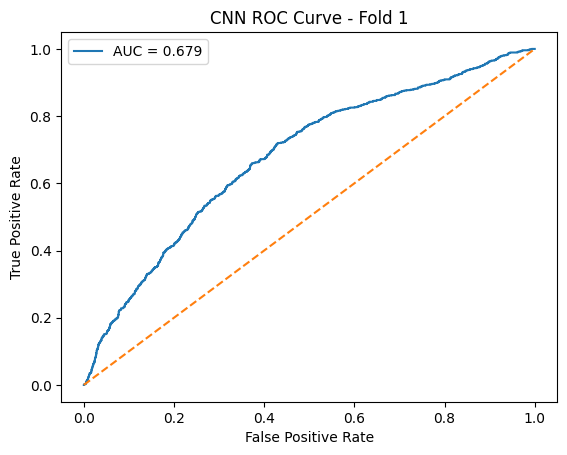

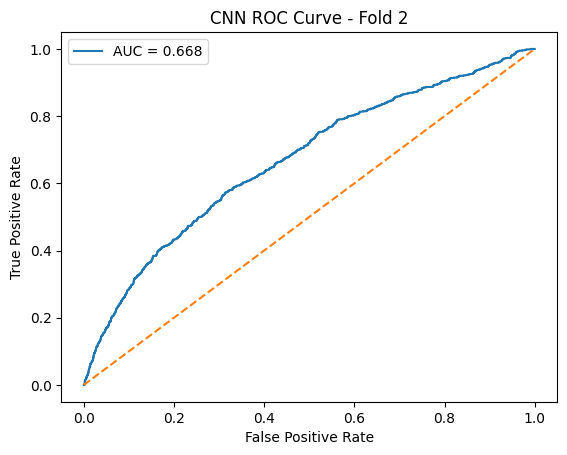

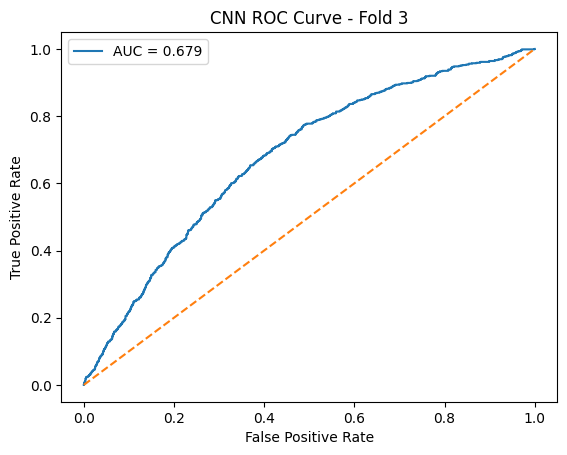

Mean AUC: 0.6752264080746193


In [21]:
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import os

PRED_DIR = os.path.join(OUTPUT_DIR, "cnn_predictions")

all_aucs = []

for fold_idx in [1, 2, 3]:

    path = os.path.join(PRED_DIR, f"cnn_fold_{fold_idx}.pkl")

    with open(path, "rb") as f:
        data = pickle.load(f)

    p_test = data["p_test"]
    y_test = data["y_test"]

    # compute ROC
    fpr, tpr, _ = roc_curve(y_test, p_test)
    auc = roc_auc_score(y_test, p_test)

    all_aucs.append(auc)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"CNN ROC Curve - Fold {fold_idx}")
    plt.legend()
    plt.show()

print("Mean AUC:", sum(all_aucs)/len(all_aucs))


FOLD 1 - InceptionTime


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 300, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_123 (Conv1D) │ (None, 300, 32)   │        320 │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_18    │ (None, 300, 10)   │          0 │ input_layer_12[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_124 (Conv1D) │ (None, 300, 32)   │     40,960 │ conv1d_123[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_125 (Conv1D) │ (None, 300, 32)   │     20,480 │ conv1d_123[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_126 (Conv1D) │ (None, 300, 32)   │     10,240 │ conv1d_123[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_127 (Conv1D) │ (None, 300, 32)   │        320 │ max_pooling1d_18… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_18      │ (None, 300, 128)  │          0 │ conv1d_124[0][0], │
│ (Concatenate)       │                   │            │ conv1d_125[0][0], │
│                     │                   │            │ conv1d_126[0][0], │
│                     │                   │            │ conv1d_127[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ concatenate_18[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_51       │ (None, 300, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_128 (Conv1D) │ (None, 300, 32)   │      4,096 │ activation_51[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_19    │ (None, 300, 128)  │          0 │ activation_51[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_129 (Conv1D) │ (None, 300, 32)   │     40,960 │ conv1d_128[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_130 (Conv1D) │ (None, 300, 32)   │     20,480 │ conv1d_128[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_131 (Conv1D) │ (None, 300, 32)   │     10,240 │ conv1d_128[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_132 (Conv1D) │ (None, 300, 32)   │      4,096 │ max_pooling1d_19… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_19      │ (None, 300, 128)  │          0 │ conv1d_129[0][0], │
│ (Concatenate)       │                   │            │ conv1d_130[0][0], │
│                     │                   │            │ conv1d_131[0][0], │
│                     │                   │            │ conv1d_132[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ concatenate_19[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_52       │ (None, 300, 128)  │          0 │ batch_normalizat

 Total params: 493,698 (1.88 MB)

 Trainable params: 491,650 (1.88 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 85s 616ms/step - accuracy: 0.8180 - loss: 0.4817 - learning_rate: 0.0010
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 115s 980ms/step - accuracy: 0.8374 - loss: 0.4345 - learning_rate: 0.0010
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 90s 763ms/step - accuracy: 0.8402 - loss: 0.4245 - learning_rate: 0.0010
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 109s 922ms/step - accuracy: 0.8396 - loss: 0.4178 - learning_rate: 0.0010
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 88s 741ms/step - accuracy: 0.8402 - loss: 0.4075 - learning_rate: 0.0010
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 65s 551ms/step - accuracy: 0.8434 - loss: 0.3946 - learning_rate: 0.0010
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 75s 634ms/step - accuracy: 0.8516 - loss: 0.3820 - learning_rate: 0.0010
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 96s 743ms/step - accuracy: 0.8537 - loss: 0.3719 - learning_rate: 0.0010
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 67s 564ms/step - accuracy: 0.8561 - loss: 0.3617 - lea

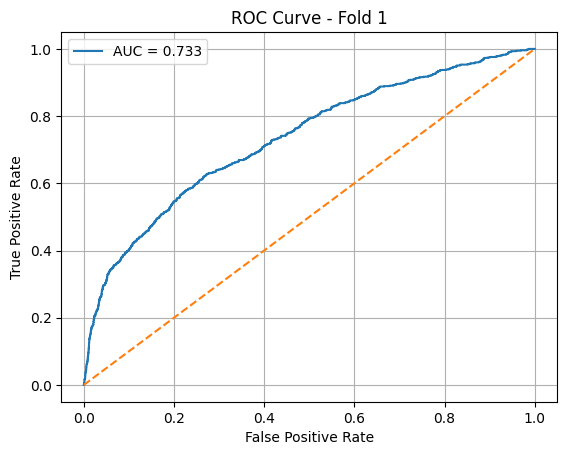

Test Log Loss: 0.5773
Best Threshold: 0.120

Confusion Matrix:
 [[3498  443]
 [ 430  320]]

Accuracy: 0.8138989554465998
FPR: 0.11240801826947475

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.891     0.888     0.889      3941
  paper_problem      0.419     0.427     0.423       750

       accuracy                          0.814      4691
      macro avg      0.655     0.657     0.656      4691
   weighted avg      0.815     0.814     0.815      4691

Saved → ./processed_data\inception_predictions\inception_fold_1.pkl

FOLD 2 - InceptionTime


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 300, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_155 (Conv1D) │ (None, 300, 32)   │        320 │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_24    │ (None, 300, 10)   │          0 │ input_layer_13[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_156 (Conv1D) │ (None, 300, 32)   │     40,960 │ conv1d_155[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_157 (Conv1D) │ (None, 300, 32)   │     20,480 │ conv1d_155[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_158 (Conv1D) │ (None, 300, 32)   │     10,240 │ conv1d_155[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_159 (Conv1D) │ (None, 300, 32)   │        320 │ max_pooling1d_24… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_24      │ (None, 300, 128)  │          0 │ conv1d_156[0][0], │
│ (Concatenate)       │                   │            │ conv1d_157[0][0], │
│                     │                   │            │ conv1d_158[0][0], │
│                     │                   │            │ conv1d_159[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ concatenate_24[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_59       │ (None, 300, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_160 (Conv1D) │ (None, 300, 32)   │      4,096 │ activation_59[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_25    │ (None, 300, 128)  │          0 │ activation_59[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_161 (Conv1D) │ (None, 300, 32)   │     40,960 │ conv1d_160[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_162 (Conv1D) │ (None, 300, 32)   │     20,480 │ conv1d_160[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_163 (Conv1D) │ (None, 300, 32)   │     10,240 │ conv1d_160[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_164 (Conv1D) │ (None, 300, 32)   │      4,096 │ max_pooling1d_25… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_25      │ (None, 300, 128)  │          0 │ conv1d_161[0][0], │
│ (Concatenate)       │                   │            │ conv1d_162[0][0], │
│                     │                   │            │ conv1d_163[0][0], │
│                     │                   │            │ conv1d_164[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ concatenate_25[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_60       │ (None, 300, 128)  │          0 │ batch_normalizat

 Total params: 493,698 (1.88 MB)

 Trainable params: 491,650 (1.88 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 64s 499ms/step - accuracy: 0.8232 - loss: 0.4753 - learning_rate: 0.0010
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 58s 495ms/step - accuracy: 0.8358 - loss: 0.4397 - learning_rate: 0.0010
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 60s 505ms/step - accuracy: 0.8372 - loss: 0.4308 - learning_rate: 0.0010
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 62s 526ms/step - accuracy: 0.8393 - loss: 0.4222 - learning_rate: 0.0010
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 58s 494ms/step - accuracy: 0.8398 - loss: 0.4071 - learning_rate: 0.0010
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 61s 515ms/step - accuracy: 0.8426 - loss: 0.3951 - learning_rate: 0.0010
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 59s 500ms/step - accuracy: 0.8469 - loss: 0.3818 - learning_rate: 0.0010
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 66s 556ms/step - accuracy: 0.8529 - loss: 0.3706 - learning_rate: 0.0010
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 60s 505ms/step - accuracy: 0.8572 - loss: 0.3601 - learn

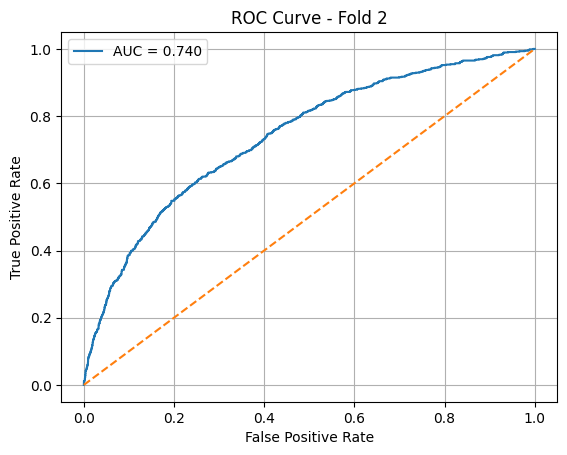

Test Log Loss: 0.6452
Best Threshold: 0.380

Confusion Matrix:
 [[3421  520]
 [ 418  332]]

Accuracy: 0.8000426348326583
FPR: 0.13194620654656178

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.891     0.868     0.879      3941
  paper_problem      0.390     0.443     0.414       750

       accuracy                          0.800      4691
      macro avg      0.640     0.655     0.647      4691
   weighted avg      0.811     0.800     0.805      4691

Saved → ./processed_data\inception_predictions\inception_fold_2.pkl

FOLD 3 - InceptionTime


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 300, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_187 (Conv1D) │ (None, 300, 32)   │        320 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_30    │ (None, 300, 10)   │          0 │ input_layer_14[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_188 (Conv1D) │ (None, 300, 32)   │     40,960 │ conv1d_187[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_189 (Conv1D) │ (None, 300, 32)   │     20,480 │ conv1d_187[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_190 (Conv1D) │ (None, 300, 32)   │     10,240 │ conv1d_187[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_191 (Conv1D) │ (None, 300, 32)   │        320 │ max_pooling1d_30… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_30      │ (None, 300, 128)  │          0 │ conv1d_188[0][0], │
│ (Concatenate)       │                   │            │ conv1d_189[0][0], │
│                     │                   │            │ conv1d_190[0][0], │
│                     │                   │            │ conv1d_191[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ concatenate_30[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_67       │ (None, 300, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_192 (Conv1D) │ (None, 300, 32)   │      4,096 │ activation_67[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_31    │ (None, 300, 128)  │          0 │ activation_67[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_193 (Conv1D) │ (None, 300, 32)   │     40,960 │ conv1d_192[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_194 (Conv1D) │ (None, 300, 32)   │     20,480 │ conv1d_192[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_195 (Conv1D) │ (None, 300, 32)   │     10,240 │ conv1d_192[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_196 (Conv1D) │ (None, 300, 32)   │      4,096 │ max_pooling1d_31… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_31      │ (None, 300, 128)  │          0 │ conv1d_193[0][0], │
│ (Concatenate)       │                   │            │ conv1d_194[0][0], │
│                     │                   │            │ conv1d_195[0][0], │
│                     │                   │            │ conv1d_196[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ concatenate_31[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_68       │ (None, 300, 128)  │          0 │ batch_normalizat

 Total params: 493,698 (1.88 MB)

 Trainable params: 491,650 (1.88 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 68s 516ms/step - accuracy: 0.8320 - loss: 0.4622 - learning_rate: 0.0010
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 58s 492ms/step - accuracy: 0.8392 - loss: 0.4305 - learning_rate: 0.0010
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 56s 476ms/step - accuracy: 0.8393 - loss: 0.4211 - learning_rate: 0.0010
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 56s 477ms/step - accuracy: 0.8381 - loss: 0.4073 - learning_rate: 0.0010
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 58s 487ms/step - accuracy: 0.8417 - loss: 0.3891 - learning_rate: 0.0010
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 55s 465ms/step - accuracy: 0.8496 - loss: 0.3749 - learning_rate: 0.0010
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 55s 464ms/step - accuracy: 0.8566 - loss: 0.3609 - learning_rate: 0.0010
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 55s 464ms/step - accuracy: 0.8616 - loss: 0.3503 - learning_rate: 0.0010
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 55s 465ms/step - accuracy: 0.8653 - loss: 0.3419 - learn

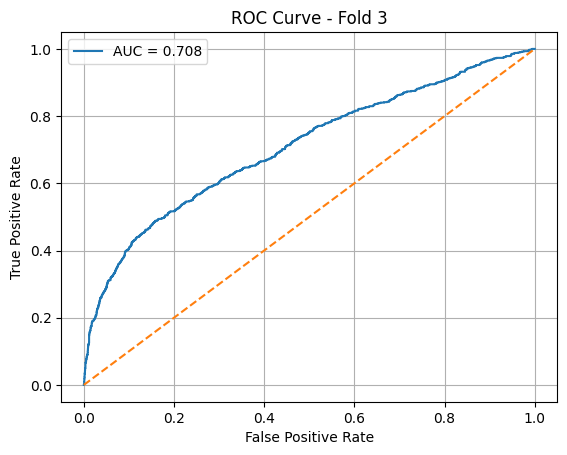

Test Log Loss: 0.7001
Best Threshold: 0.080

Confusion Matrix:
 [[3676  264]
 [ 503  248]]

Accuracy: 0.8364954167554892
FPR: 0.06700507614213198

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.880     0.933     0.906      3940
  paper_problem      0.484     0.330     0.393       751

       accuracy                          0.836      4691
      macro avg      0.682     0.632     0.649      4691
   weighted avg      0.816     0.836     0.823      4691

Saved → ./processed_data\inception_predictions\inception_fold_3.pkl

############################################################
INCEPTION FINAL SUMMARY
############################################################
AUCs: [0.7329, 0.7401, 0.708]
Mean AUC: 0.7270157606022692

Test Losses: [0.5773, 0.6452, 0.7001]
Mean Test Loss: 0.6408655896618417


In [ ]:
# ============================================================
# INCEPTIONTIME Classifier
# ============================================================

from sktime.classification.deep_learning.inceptiontime import InceptionTimeClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, log_loss, roc_curve
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt


# -------------------------
# Helper: convert shape
# -------------------------
def to_sktime_format(X):
    return np.transpose(X, (0, 2, 1)).astype(np.float32)


# -------------------------
# Threshold tuning
# -------------------------
def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 91)

    best_thr = 0.5
    best_f1 = -1

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        if cm.shape != (2, 2):
            continue

        tn, fp, fn, tp = cm.ravel()

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr


# -------------------------
# Output dir
# -------------------------
PRED_DIR = os.path.join(OUTPUT_DIR, "inception_predictions")
os.makedirs(PRED_DIR, exist_ok=True)


results = []

# ============================================================
# RUN CV
# ============================================================
for fold_data in cv_folds:

    fold_idx = fold_data["fold"]

    print("\n" + "="*60)
    print(f"FOLD {fold_idx} - InceptionTime")
    print("="*60)

    X_train = to_sktime_format(fold_data["X_train"])
    X_val   = to_sktime_format(fold_data["X_val"])
    X_test  = to_sktime_format(fold_data["X_test"])

    y_train = fold_data["y_train"]
    y_val   = fold_data["y_val"]
    y_test  = fold_data["y_test"]

    # -------------------------
    # Model
    # -------------------------
    model = InceptionTimeClassifier(
        n_epochs=30,
        batch_size=64,
        verbose=True,
        random_state=SEED
    )

    model.fit(X_train, y_train)

    # -------------------------
    # TRAINING LOSS 
    # -------------------------
    hist = getattr(model, "history_", None)
    loss = None

    if hist is None:
        print("No training history available")

    elif isinstance(hist, dict):
        loss = hist.get("loss", None)

    elif hasattr(hist, "history"):
        loss = hist.history.get("loss", None)

    if loss is not None:
        plt.figure()
        plt.plot(loss, marker='o')
        plt.title(f"Training Loss - Fold {fold_idx}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()
    else:
        print("Training loss not found")

    # -------------------------
    # Predictions
    # -------------------------
    p_val = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    # -------------------------
    # AUC + ROC
    # -------------------------
    auc = roc_auc_score(y_test, p_test)
    print(f"AUC: {auc:.4f}")

    fpr_vals, tpr_vals, _ = roc_curve(y_test, p_test)

    plt.figure()
    plt.plot(fpr_vals, tpr_vals, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Fold {fold_idx}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # TEST LOSS
    # -------------------------
    test_loss = log_loss(y_test, p_test)
    print(f"Test Log Loss: {test_loss:.4f}")

    # -------------------------
    # Threshold tuning
    # -------------------------
    thr = find_best_threshold(y_val, p_val)
    print(f"Best Threshold: {thr:.3f}")

    y_pred = (p_test >= thr).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn)

    report = classification_report(
        y_test,
        y_pred,
        target_names=["machine_problem", "paper_problem"],
        digits=3,
        zero_division=0
    )

    print("\nConfusion Matrix:\n", cm)
    print("\nAccuracy:", acc)
    print("FPR:", fpr)
    print("\nClassification Report:\n", report)

    # -------------------------
    # SAVE EVERYTHING
    # -------------------------
    path = os.path.join(PRED_DIR, f"inception_fold_{fold_idx}.pkl")

    with open(path, "wb") as f:
        pickle.dump({
            "fold": fold_idx,
            "p_val": p_val,
            "p_test": p_test,
            "y_val": y_val,
            "y_test": y_test,
            "threshold": thr,
            "auc": auc,
            "test_loss": test_loss,
            "accuracy": acc,
            "fpr": fpr,
            "confusion_matrix": cm,
            "classification_report": report
        }, f)

    print(f"Saved → {path}")

    results.append({
        "auc": auc,
        "loss": test_loss
    })


# -------------------------
# FINAL SUMMARY
# -------------------------
print("\n" + "#"*60)
print("INCEPTION FINAL SUMMARY")
print("#"*60)

print("AUCs:", [round(x["auc"], 4) for x in results])
print("Mean AUC:", np.mean([x["auc"] for x in results]))

print("\nTest Losses:", [round(x["loss"], 4) for x in results])
print("Mean Test Loss:", np.mean([x["loss"] for x in results]))


FOLD 1 - LSTM-FCN


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 300, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_219 (Conv1D) │ (None, 300, 128)  │     10,368 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_219[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_75       │ (None, 300, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_220 (Conv1D) │ (None, 300, 256)  │    164,096 │ activation_75[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_220[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_76       │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_221 (Conv1D) │ (None, 300, 128)  │     98,432 │ activation_76[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_221[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 8)         │        608 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_77       │ (None, 300, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8)         │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_77[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_36      │ (None, 136)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 2)         │        274 │ concatenate_36[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 275,826 (1.05 MB)

 Trainable params: 274,802 (1.05 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 34s 259ms/step - accuracy: 0.8241 - loss: 0.4672
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 252ms/step - accuracy: 0.8377 - loss: 0.4324
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 254ms/step - accuracy: 0.8380 - loss: 0.4256
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 250ms/step - accuracy: 0.8394 - loss: 0.4191
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 251ms/step - accuracy: 0.8398 - loss: 0.4136
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 257ms/step - accuracy: 0.8384 - loss: 0.4125
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 253ms/step - accuracy: 0.8398 - loss: 0.4055
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 252ms/step - accuracy: 0.8397 - loss: 0.4045
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 247ms/step - accuracy: 0.8402 - loss: 0.4009
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 250ms/step - accuracy: 0.8394 - loss: 0.3965
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 257ms/step - accuracy: 0.8393 - loss: 0.3945
Epoch 12/30
118/118

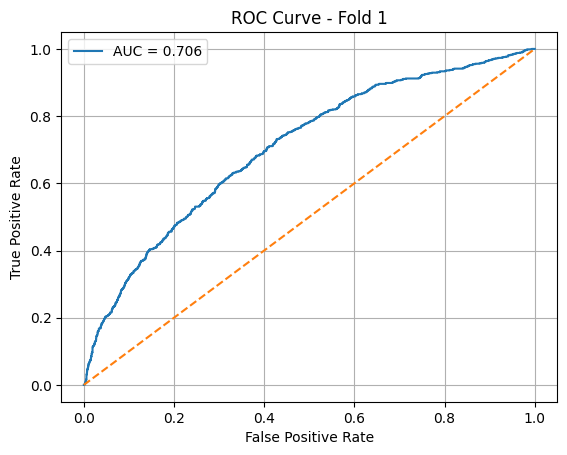

Test Log Loss: 0.4323
Best Threshold: 0.250

Confusion Matrix:
 [[3111  830]
 [ 387  363]]

Accuracy: 0.7405670432743552
FPR: 0.21060644506470438

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.889     0.789     0.836      3941
  paper_problem      0.304     0.484     0.374       750

       accuracy                          0.741      4691
      macro avg      0.597     0.637     0.605      4691
   weighted avg      0.796     0.741     0.762      4691

Saved → ./processed_data\lstmfcn_predictions\lstmfcn_fold_1.pkl

FOLD 2 - LSTM-FCN


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 300, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_222 (Conv1D) │ (None, 300, 128)  │     10,368 │ input_layer_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_222[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_78       │ (None, 300, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_223 (Conv1D) │ (None, 300, 256)  │    164,096 │ activation_78[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_223[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_79       │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_224 (Conv1D) │ (None, 300, 128)  │     98,432 │ activation_79[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_224[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 8)         │        608 │ input_layer_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_80       │ (None, 300, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8)         │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_80[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_37      │ (None, 136)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 2)         │        274 │ concatenate_37[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 275,826 (1.05 MB)

 Trainable params: 274,802 (1.05 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 34s 254ms/step - accuracy: 0.8301 - loss: 0.4610
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 32s 273ms/step - accuracy: 0.8390 - loss: 0.4286
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 33s 279ms/step - accuracy: 0.8376 - loss: 0.4240
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 31s 266ms/step - accuracy: 0.8396 - loss: 0.4209
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 31s 261ms/step - accuracy: 0.8390 - loss: 0.4159
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 256ms/step - accuracy: 0.8400 - loss: 0.4111
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 249ms/step - accuracy: 0.8389 - loss: 0.4101
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 252ms/step - accuracy: 0.8404 - loss: 0.4068
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 251ms/step - accuracy: 0.8405 - loss: 0.4010
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 250ms/step - accuracy: 0.8409 - loss: 0.4028
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 31s 259ms/step - accuracy: 0.8414 - loss: 0.3991
Epoch 12/30
118/118

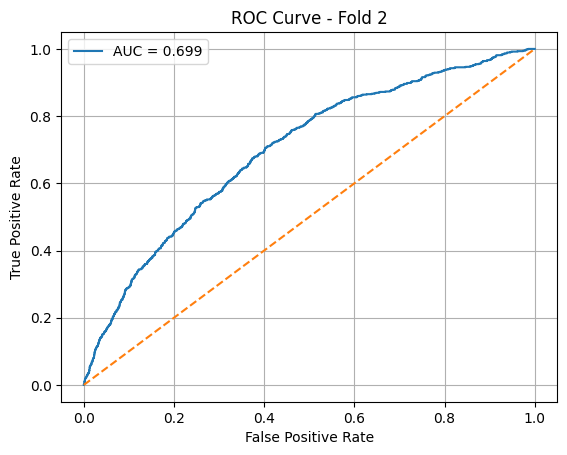

Test Log Loss: 0.4285
Best Threshold: 0.160

Confusion Matrix:
 [[2893 1048]
 [ 340  410]]

Accuracy: 0.7041142613515242
FPR: 0.26592235473230147

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.895     0.734     0.807      3941
  paper_problem      0.281     0.547     0.371       750

       accuracy                          0.704      4691
      macro avg      0.588     0.640     0.589      4691
   weighted avg      0.797     0.704     0.737      4691

Saved → ./processed_data\lstmfcn_predictions\lstmfcn_fold_2.pkl

FOLD 3 - LSTM-FCN


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 300, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_225 (Conv1D) │ (None, 300, 128)  │     10,368 │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_225[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_81       │ (None, 300, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_226 (Conv1D) │ (None, 300, 256)  │    164,096 │ activation_81[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_226[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_82       │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_227 (Conv1D) │ (None, 300, 128)  │     98,432 │ activation_82[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_227[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 8)         │        608 │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_83       │ (None, 300, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8)         │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_83[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_38      │ (None, 136)       │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 2)         │        274 │ concatenate_38[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 275,826 (1.05 MB)

 Trainable params: 274,802 (1.05 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 31s 240ms/step - accuracy: 0.8301 - loss: 0.4714
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 242ms/step - accuracy: 0.8385 - loss: 0.4285
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 242ms/step - accuracy: 0.8380 - loss: 0.4198
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 28s 241ms/step - accuracy: 0.8394 - loss: 0.4137
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 28s 241ms/step - accuracy: 0.8398 - loss: 0.4114
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 28s 241ms/step - accuracy: 0.8398 - loss: 0.4078
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 242ms/step - accuracy: 0.8409 - loss: 0.4035
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 242ms/step - accuracy: 0.8412 - loss: 0.4006
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 254ms/step - accuracy: 0.8414 - loss: 0.3955
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 242ms/step - accuracy: 0.8414 - loss: 0.3942
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 243ms/step - accuracy: 0.8402 - loss: 0.3935
Epoch 12/30
118/118

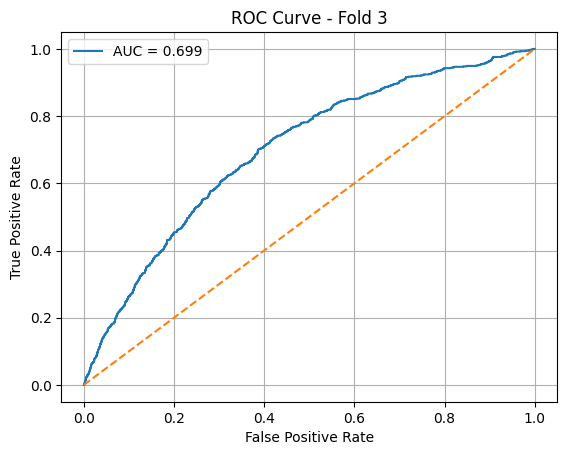

Test Log Loss: 0.4528
Best Threshold: 0.110

Confusion Matrix:
 [[2611 1329]
 [ 272  479]]

Accuracy: 0.6587081645704541
FPR: 0.33730964467005076

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.906     0.663     0.765      3940
  paper_problem      0.265     0.638     0.374       751

       accuracy                          0.659      4691
      macro avg      0.585     0.650     0.570      4691
   weighted avg      0.803     0.659     0.703      4691

Saved → ./processed_data\lstmfcn_predictions\lstmfcn_fold_3.pkl

############################################################
LSTM-FCN FINAL SUMMARY
############################################################
AUCs: [0.706, 0.6986, 0.6994]
Mean AUC: 0.7013463321495657

Test Losses: [0.4323, 0.4285, 0.4528]
Mean Test Loss: 0.4378808118231301


In [ ]:
# ============================================================
# LSTM-FCN Classifier
# ============================================================

from sktime.classification.deep_learning.lstmfcn import LSTMFCNClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, log_loss, roc_curve
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt


def to_sktime_format(X):
    return np.transpose(X, (0, 2, 1)).astype(np.float32)


def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 91)

    best_thr = 0.5
    best_f1 = -1

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        if cm.shape != (2, 2):
            continue

        tn, fp, fn, tp = cm.ravel()

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr


# -------------------------
# Output dir
# -------------------------
PRED_DIR = os.path.join(OUTPUT_DIR, "lstmfcn_predictions")
os.makedirs(PRED_DIR, exist_ok=True)


results = []

# ============================================================
# RUN CV
# ============================================================
for fold_data in cv_folds:

    fold_idx = fold_data["fold"]

    print("\n" + "="*60)
    print(f"FOLD {fold_idx} - LSTM-FCN")
    print("="*60)

    X_train = to_sktime_format(fold_data["X_train"])
    X_val   = to_sktime_format(fold_data["X_val"])
    X_test  = to_sktime_format(fold_data["X_test"])

    y_train = fold_data["y_train"]
    y_val   = fold_data["y_val"]
    y_test  = fold_data["y_test"]

    # -------------------------
    # Model
    # -------------------------
    model = LSTMFCNClassifier(
        n_epochs=30,
        batch_size=64,
        verbose=True,
        random_state=SEED
    )

    # -------------------------
    # Train
    # -------------------------
    model.fit(X_train, y_train)

    # -------------------------
    # TRAINING LOSS (ROBUST)
    # -------------------------
    hist = getattr(model, "history_", None)
    loss = None

    if hist is None:
        print("No training history available")

    elif isinstance(hist, dict):
        loss = hist.get("loss", None)

    elif hasattr(hist, "history"):
        loss = hist.history.get("loss", None)

    if loss is not None:
        plt.figure()
        plt.plot(loss, marker='o')
        plt.title(f"Training Loss - Fold {fold_idx}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()
    else:
        print("Training loss not found")

    # -------------------------
    # Predictions
    # -------------------------
    p_val = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    # -------------------------
    # AUC + ROC
    # -------------------------
    auc = roc_auc_score(y_test, p_test)
    print(f"AUC: {auc:.4f}")

    fpr_vals, tpr_vals, _ = roc_curve(y_test, p_test)

    plt.figure()
    plt.plot(fpr_vals, tpr_vals, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Fold {fold_idx}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # TEST LOSS
    # -------------------------
    test_loss = log_loss(y_test, p_test)
    print(f"Test Log Loss: {test_loss:.4f}")

    # -------------------------
    # Threshold tuning
    # -------------------------
    thr = find_best_threshold(y_val, p_val)
    print(f"Best Threshold: {thr:.3f}")

    y_pred = (p_test >= thr).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn)

    report = classification_report(
        y_test,
        y_pred,
        target_names=["machine_problem", "paper_problem"],
        digits=3,
        zero_division=0
    )

    print("\nConfusion Matrix:\n", cm)
    print("\nAccuracy:", acc)
    print("FPR:", fpr)
    print("\nClassification Report:\n", report)

    # -------------------------
    # SAVE EVERYTHING
    # -------------------------
    path = os.path.join(PRED_DIR, f"lstmfcn_fold_{fold_idx}.pkl")

    with open(path, "wb") as f:
        pickle.dump({
            "fold": fold_idx,
            "p_val": p_val,
            "p_test": p_test,
            "y_val": y_val,
            "y_test": y_test,
            "threshold": thr,
            "auc": auc,
            "test_loss": test_loss,
            "accuracy": acc,
            "fpr": fpr,
            "confusion_matrix": cm,
            "classification_report": report
        }, f)

    print(f"Saved → {path}")

    results.append({
        "auc": auc,
        "loss": test_loss
    })


# -------------------------
# FINAL SUMMARY
# -------------------------
print("\n" + "#"*60)
print("LSTM-FCN FINAL SUMMARY")
print("#"*60)

print("AUCs:", [round(x["auc"], 4) for x in results])
print("Mean AUC:", np.mean([x["auc"] for x in results]))

print("\nTest Losses:", [round(x["loss"], 4) for x in results])
print("Mean Test Loss:", np.mean([x["loss"] for x in results]))

In [ ]:
# ============================================================
# TAPNET Classifier
# ============================================================

from sktime.classification.deep_learning.tapnet import TapNetClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, log_loss, roc_curve
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt


def to_sktime_format(X):
    return np.transpose(X, (0, 2, 1)).astype(np.float32)


def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 91)

    best_thr = 0.5
    best_f1 = -1

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        if cm.shape != (2, 2):
            continue

        tn, fp, fn, tp = cm.ravel()

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr


# -------------------------
# Output dir
# -------------------------
PRED_DIR = os.path.join(OUTPUT_DIR, "tapnet_predictions")
os.makedirs(PRED_DIR, exist_ok=True)


results = []

# ============================================================
# RUN CV
# ============================================================
for fold_data in cv_folds:

    fold_idx = fold_data["fold"]

    print("\n" + "="*60)
    print(f"FOLD {fold_idx} - TapNet")
    print("="*60)

    X_train = to_sktime_format(fold_data["X_train"])
    X_val   = to_sktime_format(fold_data["X_val"])
    X_test  = to_sktime_format(fold_data["X_test"])

    y_train = fold_data["y_train"]
    y_val   = fold_data["y_val"]
    y_test  = fold_data["y_test"]

    # -------------------------
    # Class weighting
    # -------------------------
    import tensorflow as tf

    n_machine    = int(np.sum(y_train == 0))
    n_paper      = int(np.sum(y_train == 1))
    paper_weight = float(n_machine / n_paper)

    print(f"Class weight — machine: 1.0x  paper: {paper_weight:.2f}x")

    def weighted_crossentropy(y_true, y_pred):
        # TapNet passes y_true as one-hot [batch, 2]
        y_true_int = tf.cast(tf.argmax(y_true, axis=-1), tf.int32)
        ce = tf.keras.losses.sparse_categorical_crossentropy(
            y_true_int, y_pred)
        weights = tf.where(
            tf.equal(y_true_int, 1),
            tf.fill(tf.shape(y_true_int), paper_weight),
            tf.ones(tf.shape(y_true_int))
        )
        return tf.reduce_mean(ce * tf.cast(weights, tf.float32))

    # -------------------------
    # Model
    # -------------------------
    model = TapNetClassifier(
        n_epochs=30,
        batch_size=64,
        verbose=True,
        random_state=SEED,
        loss=weighted_crossentropy,
    )

    # -------------------------
    # Train
    # -------------------------
    model.fit(X_train, y_train)

    # -------------------------
    # TRAINING LOSS 
    # -------------------------
    hist = getattr(model, "history_", None)
    loss = None

    if hist is None:
        print("No training history available")

    elif isinstance(hist, dict):
        loss = hist.get("loss", None)

    elif hasattr(hist, "history"):
        loss = hist.history.get("loss", None)

    if loss is not None:
        plt.figure()
        plt.plot(loss, marker='o')
        plt.title(f"Training Loss - Fold {fold_idx}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()
    else:
        print("Training loss not found")

    # -------------------------
    # Predictions
    # -------------------------
    p_val = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    # -------------------------
    # AUC + ROC
    # -------------------------
    auc = roc_auc_score(y_test, p_test)
    print(f"AUC: {auc:.4f}")

    fpr_vals, tpr_vals, _ = roc_curve(y_test, p_test)

    plt.figure()
    plt.plot(fpr_vals, tpr_vals, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Fold {fold_idx}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # TEST LOSS
    # -------------------------
    test_loss = log_loss(y_test, p_test)
    print(f"Test Log Loss: {test_loss:.4f}")

    # -------------------------
    # Threshold tuning
    # -------------------------
    thr = find_best_threshold(y_val, p_val)
    print(f"Best Threshold: {thr:.3f}")

    y_pred = (p_test >= thr).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn)

    report = classification_report(
        y_test,
        y_pred,
        target_names=["machine_problem", "paper_problem"],
        digits=3,
        zero_division=0
    )

    print("\nConfusion Matrix:\n", cm)
    print("\nAccuracy:", acc)
    print("FPR:", fpr)
    print("\nClassification Report:\n", report)

    # -------------------------
    # SAVE EVERYTHING
    # -------------------------
    path = os.path.join(PRED_DIR, f"tapnet_fold_{fold_idx}.pkl")

    with open(path, "wb") as f:
        pickle.dump({
            "fold": fold_idx,
            "p_val": p_val,
            "p_test": p_test,
            "y_val": y_val,
            "y_test": y_test,
            "threshold": thr,
            "auc": auc,
            "test_loss": test_loss,
            "accuracy": acc,
            "fpr": fpr,
            "confusion_matrix": cm,
            "classification_report": report
        }, f)

    print(f"Saved → {path}")

    results.append({
        "auc": auc,
        "loss": test_loss
    })


# -------------------------
# FINAL SUMMARY
# -------------------------
print("\n" + "#"*60)
print("TAPNET FINAL SUMMARY")
print("#"*60)

print("AUCs:", [round(x["auc"], 4) for x in results])
print("Mean AUC:", np.mean([x["auc"] for x in results]))

print("\nTest Losses:", [round(x["loss"], 4) for x in results])
print("Mean Test Loss:", np.mean([x["loss"] for x in results]))


FOLD 1 - TapNet
Class weight — machine: 1.0x  paper: 5.25x


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 300, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 300, 10)   │          0 │ input_layer_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None, 300, 10)   │          0 │ input_layer_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_255 (Conv1D) │ (None, 300, 256)  │     20,736 │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_258 (Conv1D) │ (None, 300, 256)  │     20,736 │ lambda_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 300, 10)   │          0 │ input_layer_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_255[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_258[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_261 (Conv1D) │ (None, 300, 256)  │     20,736 │ lambda_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_114      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_117      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_261[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_256 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_114[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_259 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_117[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_120      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_256[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_259[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_262 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_120[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_115      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_118      │ (None, 300, 256)  │          0 │ batch_normalizat

 Total params: 2,976,446 (11.35 MB)

 Trainable params: 2,971,606 (11.34 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 300, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_15 (Lambda)  │ (None, 300, 10)   │          0 │ input_layer_23[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_16 (Lambda)  │ (None, 300, 10)   │          0 │ input_layer_23[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_273 (Conv1D) │ (None, 300, 256)  │     20,736 │ lambda_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_276 (Conv1D) │ (None, 300, 256)  │     20,736 │ lambda_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_17 (Lambda)  │ (None, 300, 10)   │          0 │ input_layer_23[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_273[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_276[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_279 (Conv1D) │ (None, 300, 256)  │     20,736 │ lambda_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_134      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_137      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_279[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_274 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_134[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_277 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_137[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_140      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_274[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_277[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_280 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_140[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_135      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_138      │ (None, 300, 256)  │          0 │ batch_normalizat

 Total params: 2,976,446 (11.35 MB)

 Trainable params: 2,971,606 (11.34 MB)

 Non-trainable params: 4,840 (18.91 KB)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.5214 - loss: 2.6335
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.5480 - loss: 1.1776
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.5567 - loss: 1.1556
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.5627 - loss: 1.4212
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.5779 - loss: 1.1774
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.5742 - loss: 1.1478
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.6116 - loss: 1.0583
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.6188 - loss: 1.0442
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.6404 - loss: 1.0488
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.6437 - loss: 1.1306
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.6710 - loss: 0.9844
Epoch 12/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 


FOLD 1 - ConvTimeNet
Epoch 1: Loss: 0.47534347767547025
Epoch 2: Loss: 0.3861029343837399
Epoch 3: Loss: 0.3547765404238539
Epoch 4: Loss: 0.3332512758798518
Epoch 5: Loss: 0.3107094523512711
Epoch 6: Loss: 0.29296693155321024
Epoch 7: Loss: 0.2746891102800935
Epoch 8: Loss: 0.2556876261102951
Epoch 9: Loss: 0.2393595524511095
Epoch 10: Loss: 0.22700830599514105
Epoch 11: Loss: 0.20320205832436933
Epoch 12: Loss: 0.18438815950589665
Epoch 13: Loss: 0.1616487530517881
Epoch 14: Loss: 0.1461854205482592
Epoch 15: Loss: 0.13606236587767884
Epoch 16: Loss: 0.13194584688645297
Epoch 17: Loss: 0.1273518258200611
Epoch 18: Loss: 0.12976771583622795
Epoch 19: Loss: 0.1302429537715043
Epoch 20: Loss: 0.13190638231334545
Epoch 21: Loss: 0.11223909007858927
Epoch 22: Loss: 0.10209570122661732
Epoch 23: Loss: 0.08774040691491405
Epoch 24: Loss: 0.07941647214909732
Epoch 25: Loss: 0.06309338872936571
Epoch 26: Loss: 0.05078494240987604
Epoch 27: Loss: 0.04240483918495602
Epoch 28: Loss: 0.03565932

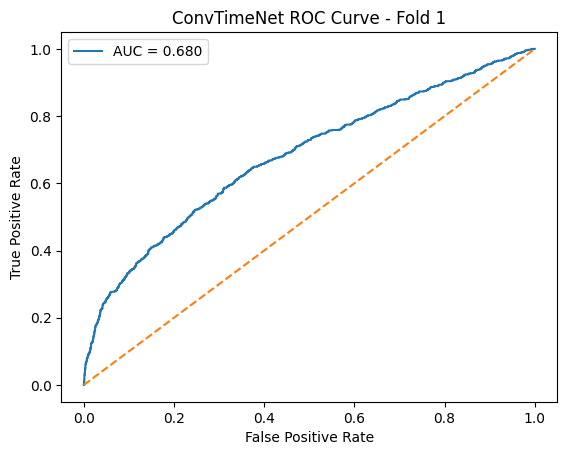

Test ROC-AUC: 0.6797
Test Log Loss: 0.7646

FOLD 2 - ConvTimeNet
Epoch 1: Loss: 0.4719721652188544
Epoch 2: Loss: 0.38470126726364684
Epoch 3: Loss: 0.35319932247117414
Epoch 4: Loss: 0.33177766784773033
Epoch 5: Loss: 0.3127332067085525
Epoch 6: Loss: 0.29415861662414117
Epoch 7: Loss: 0.2767972235836215
Epoch 8: Loss: 0.2598095976952779
Epoch 9: Loss: 0.2414716852165885
Epoch 10: Loss: 0.22334335523389154
Epoch 11: Loss: 0.20536511121475595
Epoch 12: Loss: 0.1893519956176564
Epoch 13: Loss: 0.17872795921955573
Epoch 14: Loss: 0.16164579057781878
Epoch 15: Loss: 0.1525748845237165
Epoch 16: Loss: 0.14742685129897573
Epoch 17: Loss: 0.15353051959773747
Epoch 18: Loss: 0.14508822932839394
Epoch 19: Loss: 0.15493744892715397
Epoch 20: Loss: 0.13828664530321197
Epoch 21: Loss: 0.12018786254733549
Epoch 22: Loss: 0.10501257675873527
Epoch 23: Loss: 0.0956389899128827
Epoch 24: Loss: 0.09207635098215887
Epoch 25: Loss: 0.08617719140503619
Epoch 26: Loss: 0.07520141299435143
Epoch 27: Loss: 

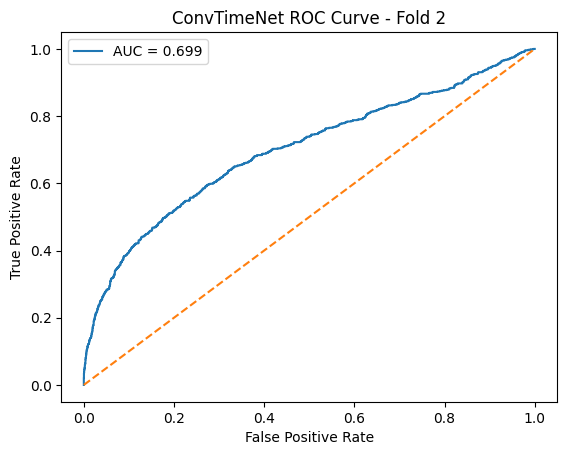

Test ROC-AUC: 0.6988
Test Log Loss: 0.7226

FOLD 3 - ConvTimeNet
Epoch 1: Loss: 0.47274239437054777
Epoch 2: Loss: 0.3814446076245631
Epoch 3: Loss: 0.3516630810701241
Epoch 4: Loss: 0.3281473868479163
Epoch 5: Loss: 0.30687867445965944
Epoch 6: Loss: 0.2872366850911561
Epoch 7: Loss: 0.2675489656374616
Epoch 8: Loss: 0.2536549625002732
Epoch 9: Loss: 0.23613523142570156
Epoch 10: Loss: 0.21947336588370597
Epoch 11: Loss: 0.20184262412584433
Epoch 12: Loss: 0.18539479854753463
Epoch 13: Loss: 0.17298348232219785
Epoch 14: Loss: 0.16242920692568108
Epoch 15: Loss: 0.14507185626711885
Epoch 16: Loss: 0.13180822058249328
Epoch 17: Loss: 0.1281982958316803
Epoch 18: Loss: 0.12355652377325094
Epoch 19: Loss: 0.11426552097802445
Epoch 20: Loss: 0.1174534239443177
Epoch 21: Loss: 0.11462559995351959
Epoch 22: Loss: 0.08608435512662439
Epoch 23: Loss: 0.07571987997172243
Epoch 24: Loss: 0.06384626413711299
Epoch 25: Loss: 0.05684268865260785
Epoch 26: Loss: 0.0519808268537587
Epoch 27: Loss: 0

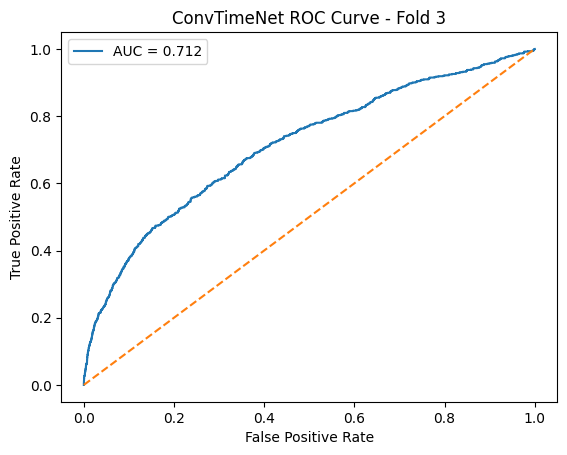

Test ROC-AUC: 0.7117
Test Log Loss: 0.7583

############################################################
CONVTIMENET FINAL RESULTS
############################################################
Fold AUCs: [0.6797, 0.6988, 0.7117]
Mean AUC: 0.6968 ± 0.0131

Fold Log Loss: [0.7646, 0.7226, 0.7583]
Mean Log Loss: 0.7485 ± 0.0185


In [ ]:
# ============================================================
# ConvTimeNet Classifier
# ============================================================

from sktime.classification.deep_learning.convtimenet import ConvTimeNetClassifier
from sklearn.metrics import roc_auc_score, roc_curve, log_loss
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os


# -------------------------
# Helper: convert shape
# -------------------------
def to_sktime_format(X):
    return np.transpose(X, (0, 2, 1)).astype(np.float32)


# -------------------------
# ROC plot
# -------------------------
def plot_roc(y_true, y_prob, fold_idx):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ConvTimeNet ROC Curve - Fold {fold_idx}")
    plt.legend()
    plt.show()

    return auc


# -------------------------
# Model save path
# -------------------------
CONVTIMENET_MODEL_DIR = os.path.join(OUTPUT_DIR, "convtimenet_models")
os.makedirs(CONVTIMENET_MODEL_DIR, exist_ok=True)


# -------------------------
# Store results
# -------------------------
convtimenet_aucs = []
convtimenet_losses = []


# -------------------------
# Run CV
# -------------------------
for fold_data in cv_folds:

    fold_idx = fold_data["fold"]

    print("\n" + "="*60)
    print(f"FOLD {fold_idx} - ConvTimeNet")
    print("="*60)

    # get data
    X_train = to_sktime_format(fold_data["X_train"])
    X_val   = to_sktime_format(fold_data["X_val"])
    X_test  = to_sktime_format(fold_data["X_test"])

    y_train = fold_data["y_train"]
    y_val   = fold_data["y_val"]
    y_test  = fold_data["y_test"]

    # -------------------------
    # Model
    # -------------------------
    model = ConvTimeNetClassifier(
        num_epochs=30,            # slightly lower (heavier model)
        batch_size=64,
        verbose=True,
        random_state=SEED,
        d_model=64,
        patch_size=16,
        patch_stride=8,
    )

    # -------------------------
    # Train
    # -------------------------
    model.fit(X_train, y_train)

    # -------------------------
    # Save model
    # -------------------------
    model_path = os.path.join(CONVTIMENET_MODEL_DIR, f"convtimenet_fold_{fold_idx}.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

    print(f"Model saved: {model_path}")

    # -------------------------
    # Predict
    # -------------------------
    p_test = model.predict_proba(X_test)[:, 1]

    # -------------------------
    # ROC + AUC
    # -------------------------
    auc = plot_roc(y_test, p_test, fold_idx)
    convtimenet_aucs.append(auc)

    # -------------------------
    # Test Loss (log loss)
    # -------------------------
    loss = log_loss(y_test, p_test)
    convtimenet_losses.append(loss)

    print(f"Test ROC-AUC: {auc:.4f}")
    print(f"Test Log Loss: {loss:.4f}")

    # -------------------------
    # Optional: Training loss
    # -------------------------
    if hasattr(model, "history_"):
        history = model.history_

        if isinstance(history, dict) and "loss" in history:
            plt.figure()
            plt.plot(history["loss"], label="train_loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title(f"ConvTimeNet Training Loss - Fold {fold_idx}")
            plt.legend()
            plt.show()


# -------------------------
# Summary
# -------------------------
print("\n" + "#"*60)
print("CONVTIMENET FINAL RESULTS")
print("#"*60)

print("Fold AUCs:", [round(x, 4) for x in convtimenet_aucs])
print(f"Mean AUC: {np.mean(convtimenet_aucs):.4f} ± {np.std(convtimenet_aucs):.4f}")

print("\nFold Log Loss:", [round(x, 4) for x in convtimenet_losses])
print(f"Mean Log Loss: {np.mean(convtimenet_losses):.4f} ± {np.std(convtimenet_losses):.4f}")

Using device: cpu

FOLD 1 - TST


AUC: 0.6684


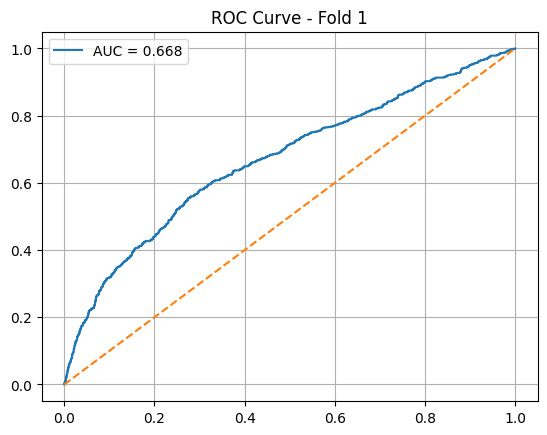

Test Log Loss: 0.7313
Best Threshold: 0.400

Confusion Matrix:
 [[3222  719]
 [ 430  320]]

Accuracy: 0.755062886378171
FPR: 0.18244100482111136

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.882     0.818     0.849      3941
  paper_problem      0.308     0.427     0.358       750

       accuracy                          0.755      4691
      macro avg      0.595     0.622     0.603      4691
   weighted avg      0.790     0.755     0.770      4691

Saved → ./processed_data\tst_predictions\tst_fold_1.pkl

FOLD 2 - TST


AUC: 0.6868


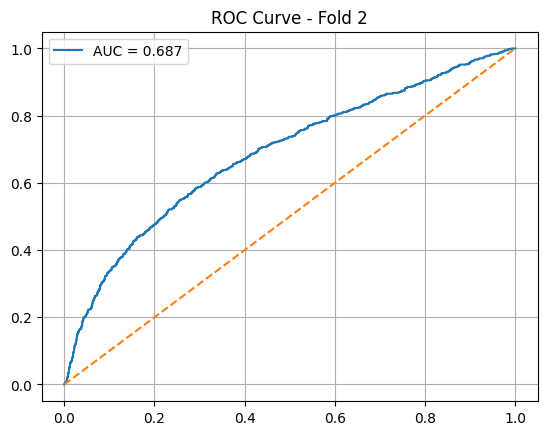

Test Log Loss: 0.7232
Best Threshold: 0.170

Confusion Matrix:
 [[2626 1315]
 [ 285  465]]

Accuracy: 0.6589213387337455
FPR: 0.3336716569398629

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.902     0.666     0.766      3941
  paper_problem      0.261     0.620     0.368       750

       accuracy                          0.659      4691
      macro avg      0.582     0.643     0.567      4691
   weighted avg      0.800     0.659     0.703      4691

Saved → ./processed_data\tst_predictions\tst_fold_2.pkl

FOLD 3 - TST


AUC: 0.6674


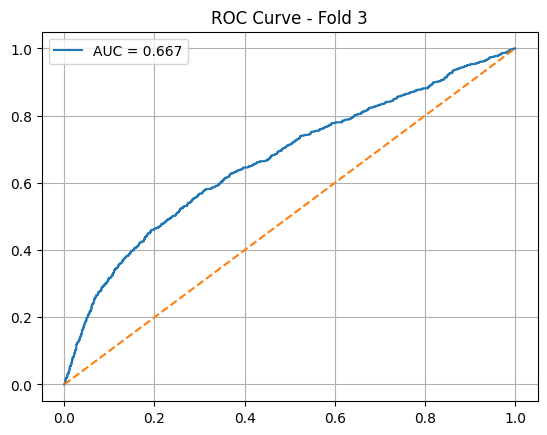

Test Log Loss: 0.7473
Best Threshold: 0.400

Confusion Matrix:
 [[3174  766]
 [ 406  345]]

Accuracy: 0.7501598806224685
FPR: 0.1944162436548223

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.887     0.806     0.844      3940
  paper_problem      0.311     0.459     0.371       751

       accuracy                          0.750      4691
      macro avg      0.599     0.632     0.607      4691
   weighted avg      0.794     0.750     0.768      4691

Saved → ./processed_data\tst_predictions\tst_fold_3.pkl

Mean AUC: 0.6742003457849043
Mean Test Loss: 0.7339250717668401


In [ ]:
# ============================================================
# TST Classifier
# ============================================================

import torch
from fastai.learner import Learner
from fastai.losses import CrossEntropyLossFlat
from tsai.all import TSDatasets, TSDataLoaders, Categorize, TST

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, log_loss, roc_curve
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os


def to_NFT(X):
    return np.transpose(X, (0, 2, 1)).astype(np.float32)


def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 91)

    best_thr = 0.5
    best_f1 = -1

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        if cm.shape != (2, 2):
            continue

        tn, fp, fn, tp = cm.ravel()

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr


PRED_DIR = os.path.join(OUTPUT_DIR, "tst_predictions")
os.makedirs(PRED_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

results = []

for fold_data in cv_folds:

    fold_idx = fold_data["fold"]

    print("\n" + "="*60)
    print(f"FOLD {fold_idx} - TST")
    print("="*60)

    X_train = to_NFT(fold_data["X_train"])
    X_val   = to_NFT(fold_data["X_val"])
    X_test  = to_NFT(fold_data["X_test"])

    y_train = fold_data["y_train"]
    y_val   = fold_data["y_val"]
    y_test  = fold_data["y_test"]

    # -------------------------
    # Combine train + val
    # -------------------------
    n_tr = len(y_train)

    X_trva = np.concatenate([X_train, X_val], axis=0)
    y_trva = np.concatenate([y_train, y_val], axis=0)

    splits = (np.arange(0, n_tr), np.arange(n_tr, len(y_trva)))

    # -------------------------
    # DataLoaders
    # -------------------------
    tfms = [None, [Categorize()]]
    dsets = TSDatasets(X_trva, y_trva, tfms=tfms, splits=splits, inplace=True)
    dls = TSDataLoaders.from_dsets(dsets.train, dsets.valid, bs=64)

    # -------------------------
    # Class weights
    # -------------------------
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    pos_weight = n_neg / n_pos

    weights = torch.tensor([1.0, pos_weight], dtype=torch.float32).to(DEVICE)

    # -------------------------
    # Model
    # -------------------------
    model = TST(
        dls.vars,
        dls.c,
        dls.len,
        d_model=64,
        n_heads=4,
        n_layers=3,
        dropout=0.2
    ).to(DEVICE)

    learn = Learner(
        dls,
        model,
        loss_func=CrossEntropyLossFlat(weight=weights)
    )

    # -------------------------
    # Train
    # -------------------------
    with learn.no_bar(), learn.no_logging():
        learn.fit_one_cycle(30, 1e-3)

    # -------------------------
    # Predictions
    # -------------------------
    val_probs, _ = learn.get_preds(dl=dls.valid)
    p_val = val_probs.cpu().numpy()[:, 1]

    test_dl = dls.valid.new_dl(X_test)
    test_probs, _ = learn.get_preds(dl=test_dl)
    p_test = test_probs.cpu().numpy()[:, 1]

    # -------------------------
    # AUC + ROC
    # -------------------------
    auc = roc_auc_score(y_test, p_test)
    print(f"AUC: {auc:.4f}")

    fpr_vals, tpr_vals, _ = roc_curve(y_test, p_test)

    plt.figure()
    plt.plot(fpr_vals, tpr_vals, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.title(f"ROC Curve - Fold {fold_idx}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # TEST LOSS
    # -------------------------
    test_loss = log_loss(y_test, p_test)
    print(f"Test Log Loss: {test_loss:.4f}")

    # -------------------------
    # Threshold tuning
    # -------------------------
    thr = find_best_threshold(y_val, p_val)
    print(f"Best Threshold: {thr:.3f}")

    y_pred = (p_test >= thr).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn + 1e-12)

    report = classification_report(
        y_test,
        y_pred,
        target_names=["machine_problem", "paper_problem"],
        digits=3,
        zero_division=0
    )

    print("\nConfusion Matrix:\n", cm)
    print("\nAccuracy:", acc)
    print("FPR:", fpr)
    print("\nClassification Report:\n", report)

    # -------------------------
    # SAVE EVERYTHING
    # -------------------------
    path = os.path.join(PRED_DIR, f"tst_fold_{fold_idx}.pkl")

    with open(path, "wb") as f:
        pickle.dump({
            "fold": fold_idx,
            "p_val": p_val,
            "p_test": p_test,
            "y_val": y_val,
            "y_test": y_test,
            "threshold": thr,
            "auc": auc,
            "test_loss": test_loss,
            "accuracy": acc,
            "fpr": fpr,
            "confusion_matrix": cm,
            "classification_report": report
        }, f)

    print(f"Saved → {path}")

    results.append({
        "auc": auc,
        "loss": test_loss
    })


print("\nMean AUC:", np.mean([x["auc"] for x in results]))
print("Mean Test Loss:", np.mean([x["loss"] for x in results]))

In [ ]:
# ============================================================
# Build XGBoost Features from X_seq
# ============================================================

import numpy as np


# -------------------------
# Helper functions
# -------------------------

def compute_entropy(probs):
    eps = 1e-12
    return -np.sum(probs * np.log(probs + eps), axis=1)


def compute_slope(x):
    t = np.arange(len(x))
    if np.std(x) < 1e-8:
        return 0.0
    return np.polyfit(t, x, 1)[0]


def compute_instability(x):
    return np.mean(np.abs(np.diff(x)))


# -------------------------
# Feature extraction
# -------------------------

def extract_features_from_sequence(X_seq, event_data):
    features = []

    for i in range(len(X_seq)):

        seq = X_seq[i]          # (300, 10)
        cam1 = seq[:, :5]
        cam2 = seq[:, 5:]

        feat = []

        for cam in [cam1, cam2]:

            # -------------------------
            # Basic stats
            # -------------------------
            feat.extend(np.mean(cam, axis=0))   # 5
            feat.extend(np.std(cam, axis=0))    # 5
            feat.extend(np.max(cam, axis=0))    # 5

            # -------------------------
            # Temporal features
            # -------------------------
            tear = cam[:, 4]
            no_defect = cam[:, 0]

            feat.append(compute_slope(tear))
            feat.append(compute_slope(no_defect))

            feat.append(np.mean(tear[-50:]))
            feat.append(np.mean(tear[:50]))
            feat.append(np.mean(tear[-50:]) - np.mean(tear[:50]))

            # -------------------------
            # Uncertainty features
            # -------------------------
            entropy = compute_entropy(cam)
            feat.append(np.mean(entropy))
            feat.append(np.std(entropy))

            # variance per channel
            feat.extend(np.var(cam, axis=0))

            # instability
            feat.append(compute_instability(tear))

            # peak sharpness
            feat.append(np.max(tear) - np.mean(tear[-50:]))

        # -------------------------
        # Cross-camera features
        # -------------------------
        cam1_tear = cam1[:, 4]
        cam2_tear = cam2[:, 4]

        feat.append(np.mean(cam1_tear) - np.mean(cam2_tear))
        feat.append(np.max(cam1_tear) - np.max(cam2_tear))

        # -------------------------
        # Camera meta features
        # -------------------------
        cam_meta = event_data[i]["cam_meta"]

        feat.append(cam_meta["padding_fraction_cam1"])
        feat.append(cam_meta["padding_fraction_cam2"])
        feat.append(cam_meta["camera2_present"])

        # -------------------------
        # Metadata features
        # -------------------------
        meta = event_data[i]["metadata"]

        feat.append(meta["speed"])
        feat.append(meta["grammage_weight"])
        feat.append(meta["web_width"])
        feat.append(meta["pap_len"])
        feat.append(meta["detector"])

        # categorical (keep raw for now)
        feat.append(meta["printer"])
        feat.append(meta["grade"])
        feat.append(meta["paper_supplier"])

        features.append(feat)

    return features


# -------------------------
# Build feature matrix
# -------------------------

X_features_raw = extract_features_from_sequence(X_seq, event_data)

print("Feature extraction done.")
print("Number of samples:", len(X_features_raw))

Feature extraction done.
Number of samples: 14073


In [ ]:
# ============================================================
# BUILD XGBOOST FEATURES 
# ============================================================

X_features_raw = extract_features_from_sequence(X_seq, event_data)

def split_features(X_features_raw):
    X_num = []
    X_cat = []

    for row in X_features_raw:
        X_num.append(row[:-3])
        X_cat.append(row[-3:])

    return np.array(X_num, dtype=float), np.array(X_cat)

X_all_num, X_all_cat = split_features(X_features_raw)

print("Feature matrix ready:")
print("X_all_num:", X_all_num.shape)
print("X_all_cat:", X_all_cat.shape)

Feature matrix ready:
X_all_num: (14073, 68)
X_all_cat: (14073, 3)



FOLD 1 - XGBoost
AUC: 0.8606


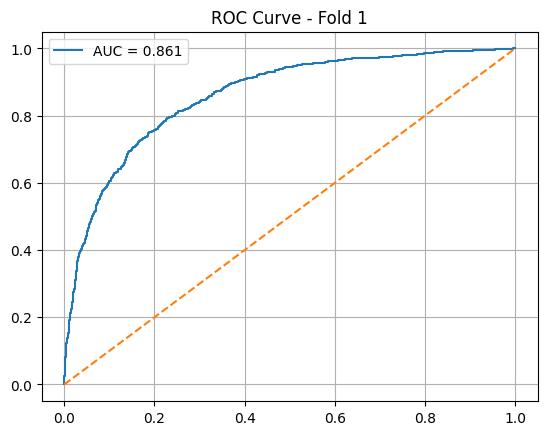

Test Log Loss: 0.3810
Best Threshold: 0.610

Confusion Matrix:
 [[3557  384]
 [ 301  449]]

Accuracy: 0.8539756981453848
FPR: 0.0974371986805379

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.922     0.903     0.912      3941
  paper_problem      0.539     0.599     0.567       750

       accuracy                          0.854      4691
      macro avg      0.730     0.751     0.740      4691
   weighted avg      0.861     0.854     0.857      4691

Saved model → ./processed_data\xgb_models\xgb_fold_1.pkl

FOLD 2 - XGBoost
AUC: 0.8597


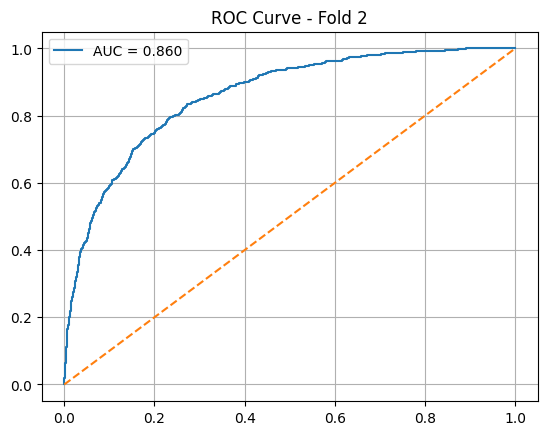

Test Log Loss: 0.3770
Best Threshold: 0.500

Confusion Matrix:
 [[3362  579]
 [ 241  509]]

Accuracy: 0.8251971861010445
FPR: 0.14691702613549856

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.933     0.853     0.891      3941
  paper_problem      0.468     0.679     0.554       750

       accuracy                          0.825      4691
      macro avg      0.700     0.766     0.723      4691
   weighted avg      0.859     0.825     0.837      4691

Saved model → ./processed_data\xgb_models\xgb_fold_2.pkl

FOLD 3 - XGBoost
AUC: 0.8583


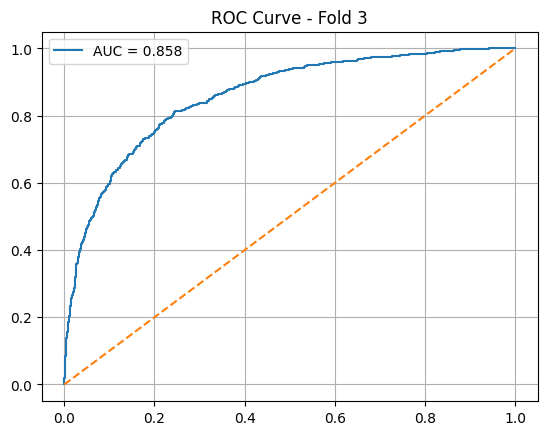

Test Log Loss: 0.3665
Best Threshold: 0.540

Confusion Matrix:
 [[3519  421]
 [ 282  469]]

Accuracy: 0.8501385632061395
FPR: 0.10685279187817256

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.926     0.893     0.909      3940
  paper_problem      0.527     0.625     0.572       751

       accuracy                          0.850      4691
      macro avg      0.726     0.759     0.740      4691
   weighted avg      0.862     0.850     0.855      4691

Saved model → ./processed_data\xgb_models\xgb_fold_3.pkl

############################################################
XGBOOST FINAL SUMMARY
############################################################
AUCs: [0.8606, 0.8597, 0.8583]
Mean AUC: 0.8595380694886771

Test Losses: [0.381, 0.377, 0.3665]
Mean Test Loss: 0.3748201026247897


In [ ]:
# ============================================================
# XGBOOST Classifier
# ============================================================

import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, log_loss, roc_curve
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
import matplotlib.pyplot as plt
import pickle
import os


# -------------------------
# Threshold tuning
# -------------------------
def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 91)

    best_thr = 0.5
    best_f1 = -1

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        if cm.shape != (2, 2):
            continue

        tn, fp, fn, tp = cm.ravel()

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr


# -------------------------
# Model save path
# -------------------------
XGB_MODEL_DIR = os.path.join(OUTPUT_DIR, "xgb_models")
os.makedirs(XGB_MODEL_DIR, exist_ok=True)


skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

results = []


for fold_idx, (train_pool_idx, test_idx) in enumerate(skf.split(X_all_num, y), start=1):

    print("\n" + "="*60)
    print(f"FOLD {fold_idx} - XGBoost")
    print("="*60)

    # -------------------------
    # Split train/val
    # -------------------------
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

    X_pool_num, y_pool = X_all_num[train_pool_idx], y[train_pool_idx]
    train_rel, val_rel = next(sss.split(X_pool_num, y_pool))

    train_idx = train_pool_idx[train_rel]
    val_idx   = train_pool_idx[val_rel]

    # numeric
    X_train_num = X_all_num[train_idx]
    X_val_num   = X_all_num[val_idx]
    X_test_num  = X_all_num[test_idx]

    # categorical
    X_train_cat = X_all_cat[train_idx]
    X_val_cat   = X_all_cat[val_idx]
    X_test_cat  = X_all_cat[test_idx]

    y_train = y[train_idx]
    y_val   = y[val_idx]
    y_test  = y[test_idx]

    # -------------------------
    # Encoding
    # -------------------------
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    X_train_ohe = ohe.fit_transform(X_train_cat)
    X_val_ohe   = ohe.transform(X_val_cat)
    X_test_ohe  = ohe.transform(X_test_cat)

    scaler = StandardScaler()
    X_train_num_s = scaler.fit_transform(X_train_num)
    X_val_num_s   = scaler.transform(X_val_num)
    X_test_num_s  = scaler.transform(X_test_num)

    X_train = np.hstack([X_train_num_s, X_train_ohe])
    X_val   = np.hstack([X_val_num_s,   X_val_ohe])
    X_test  = np.hstack([X_test_num_s,  X_test_ohe])

    # -------------------------
    # Class imbalance
    # -------------------------
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=SEED,
        early_stopping_rounds=30,
        verbosity=0,
    )

    # -------------------------
    # Train
    # -------------------------
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    # -------------------------
    # Predict
    # -------------------------
    p_val = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    # -------------------------
    # AUC + ROC
    # -------------------------
    auc = roc_auc_score(y_test, p_test)
    print(f"AUC: {auc:.4f}")

    fpr_vals, tpr_vals, _ = roc_curve(y_test, p_test)

    plt.figure()
    plt.plot(fpr_vals, tpr_vals, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.title(f"ROC Curve - Fold {fold_idx}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # Test loss
    # -------------------------
    test_loss = log_loss(y_test, p_test)
    print(f"Test Log Loss: {test_loss:.4f}")

    # -------------------------
    # Threshold tuning
    # -------------------------
    thr = find_best_threshold(y_val, p_val)
    print(f"Best Threshold: {thr:.3f}")

    y_pred = (p_test >= thr).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn + 1e-12)

    report = classification_report(
        y_test,
        y_pred,
        target_names=["machine_problem", "paper_problem"],
        digits=3,
        zero_division=0
    )

    print("\nConfusion Matrix:\n", cm)
    print("\nAccuracy:", acc)
    print("FPR:", fpr)
    print("\nClassification Report:\n", report)

    # -------------------------
    # SAVE MODEL (VALID HERE)
    # -------------------------
    model_path = os.path.join(XGB_MODEL_DIR, f"xgb_fold_{fold_idx}.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

    print(f"Saved model → {model_path}")

    # -------------------------
    # SAVE RESULTS
    # -------------------------
    results.append({
        "auc": auc,
        "loss": test_loss
    })


# -------------------------
# FINAL SUMMARY
# -------------------------
print("\n" + "#"*60)
print("XGBOOST FINAL SUMMARY")
print("#"*60)

print("AUCs:", [round(x["auc"], 4) for x in results])
print("Mean AUC:", np.mean([x["auc"] for x in results]))

print("\nTest Losses:", [round(x["loss"], 4) for x in results])
print("Mean Test Loss:", np.mean([x["loss"] for x in results]))

In [ ]:
# ============================================================
# FEATURE IMPORTANCE PLOT 
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# -------------------------
# Reconstruct feature names
# -------------------------

# Numerical feature names (63 features, in order of extraction)
score_names = ["no_defect", "defect", "rollenwechsel", "kantenfehler", "tear"]
cam_names = ["cam1", "cam2"]

num_feature_names = []

for cam in cam_names:
    # mean (5), std (5), max (5)
    for stat in ["mean", "std", "max"]:
        for s in score_names:
            num_feature_names.append(f"{cam}_{s}_{stat}")
    # temporal (5)
    num_feature_names.append(f"{cam}_tear_slope")
    num_feature_names.append(f"{cam}_no_defect_slope")
    num_feature_names.append(f"{cam}_tear_mean_last50")
    num_feature_names.append(f"{cam}_tear_mean_first50")
    num_feature_names.append(f"{cam}_tear_diff_50")
    # uncertainty (9)
    num_feature_names.append(f"{cam}_entropy_mean")
    num_feature_names.append(f"{cam}_entropy_std")
    for s in score_names:
        num_feature_names.append(f"{cam}_{s}_variance")
    num_feature_names.append(f"{cam}_tear_instability")
    num_feature_names.append(f"{cam}_tear_peak_sharpness")

# cross-camera (2)
num_feature_names.append("cross_cam_tear_mean_diff")
num_feature_names.append("cross_cam_tear_max_diff")

# auxiliary (3)
num_feature_names.append("padding_fraction_cam1")
num_feature_names.append("padding_fraction_cam2")
num_feature_names.append("camera2_present")

# metadata numeric (5)
num_feature_names.append("speed")
num_feature_names.append("grammage_weight")
num_feature_names.append("web_width")
num_feature_names.append("pap_len")
num_feature_names.append("detector")

print(f"Numerical feature count: {len(num_feature_names)}")  # should be 68

# -------------------------
# Get OHE feature names
# Refit OHE on full dataset to get category names
# -------------------------

ohe_full = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_full.fit(X_all_cat)

cat_feature_names = []
cat_cols = ["printer", "grade", "paper_supplier"]
for col_idx, col_name in enumerate(cat_cols):
    for category in ohe_full.categories_[col_idx]:
        cat_feature_names.append(f"{col_name}_{category}")

print(f"Categorical (OHE) feature count: {len(cat_feature_names)}")

# -------------------------
# All feature names combined
# -------------------------

all_feature_names = num_feature_names + cat_feature_names
print(f"Total feature count: {len(all_feature_names)}")

# -------------------------
# Average importance across folds
# -------------------------

# Load saved models
fold_importances = []

for fold_idx in range(1, 4):
    model_path = os.path.join(XGB_MODEL_DIR, f"xgb_fold_{fold_idx}.pkl")
    with open(model_path, "rb") as f:
        loaded_model = pickle.load(f)

    # importance length may differ from all_feature_names if OHE
    # categories differ per fold — use gain importance
    imp = loaded_model.get_booster().get_score(importance_type='gain')

    # XGBoost names features as f0, f1, f2... when no feature names set
    # Map by index
    n_features = len(all_feature_names)
    imp_array = np.zeros(n_features)
    for k, v in imp.items():
        idx = int(k.replace("f", ""))
        if idx < n_features:
            imp_array[idx] = v

    fold_importances.append(imp_array)

mean_importance = np.mean(fold_importances, axis=0)

# Normalize
mean_importance = mean_importance / mean_importance.sum()

# -------------------------
# Plot top 30
# -------------------------

top_n = 30
top_indices = np.argsort(mean_importance)[::-1][:top_n]
top_names = [all_feature_names[i] for i in top_indices]
top_values = mean_importance[top_indices]

# Color by feature type
def get_color(name):
    if any(name.startswith(p) for p in ["printer_", "grade_", "paper_supplier_"]):
        return "#E07B39"   # orange - categorical metadata
    elif any(name.startswith(p) for p in ["speed", "grammage", "web_width",
                                            "pap_len", "detector"]):
        return "#5B8DB8"   # blue - numeric metadata
    else:
        return "#4A9B6F"   # green - time series features

colors = [get_color(n) for n in top_names]

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(range(top_n), top_values[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_xlabel("Normalised Feature Importance (mean gain, averaged across 3 folds)")
ax.set_title("Top 30 Features — XGBoost Full Model\n(Green = time series, Orange = categorical metadata, Blue = numeric metadata)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "xgb_feature_importance_top30.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 features:")
for i, (name, val) in enumerate(zip(top_names[:10], top_values[:10])):
    print(f"  {i+1:2d}. {name:<45} {val:.4f}")

In [ ]:
# ============================================================
# CELL: XGBoost Ablation — Time Series Features Only
# (No metadata: drop speed, grammage_weight, web_width,
#  pap_len, detector and all categorical variables)
# Compare AUC to full model (0.8595) to isolate metadata
# contribution
# ============================================================

import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, log_loss, confusion_matrix, classification_report, roc_curve
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
import matplotlib.pyplot as plt
import pickle
import os

# -------------------------
# Build TS-only feature matrix
# X_all_num has 68 columns:
#   cols 0-62  : time series features (63 features)
#   cols 63-67 : metadata: speed, grammage, web_width, pap_len, detector (5 features)
# X_all_cat   : printer, grade, paper_supplier (3 categorical — excluded entirely)
# -------------------------

X_ts_only = X_all_num[:, :63]   # drop last 5 metadata columns
# No X_all_cat — categorical metadata excluded

print(f"TS-only feature matrix shape: {X_ts_only.shape}")
print(f"Full feature matrix shape:    {X_all_num.shape}")
print(f"Features dropped: {X_all_num.shape[1] - X_ts_only.shape[1]} numeric + 3 categorical")


# -------------------------
# Threshold tuning (same as main XGBoost cell)
# -------------------------
def find_best_threshold_ablation(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_thr, best_f1 = 0.5, -1
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        if cm.shape != (2, 2):
            continue
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp + 1e-12)
        recall    = tp / (tp + fn + 1e-12)
        f1        = 2 * precision * recall / (precision + recall + 1e-12)
        if f1 > best_f1:
            best_f1  = f1
            best_thr = thr
    return best_thr


# -------------------------
# CV setup : identical splits to main XGBoost
# (same SEED and StratifiedKFold ensures same folds)
# -------------------------
skf_ablation = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

ablation_results = []

for fold_idx, (train_pool_idx, test_idx) in enumerate(
        skf_ablation.split(X_ts_only, y), start=1):

    print("\n" + "="*60)
    print(f"FOLD {fold_idx} - XGBoost (TS-only, no metadata)")
    print("="*60)

    # split train / val
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    X_pool, y_pool = X_ts_only[train_pool_idx], y[train_pool_idx]
    train_rel, val_rel = next(sss.split(X_pool, y_pool))

    train_idx = train_pool_idx[train_rel]
    val_idx   = train_pool_idx[val_rel]

    X_train = X_ts_only[train_idx]
    X_val   = X_ts_only[val_idx]
    X_test  = X_ts_only[test_idx]

    y_train = y[train_idx]
    y_val   = y[val_idx]
    y_test  = y[test_idx]

    print(f"TRAIN: {X_train.shape}  counts: {np.bincount(y_train)}")
    print(f"VAL  : {X_val.shape}   counts: {np.bincount(y_val)}")
    print(f"TEST : {X_test.shape}  counts: {np.bincount(y_test)}")

    # Scale numeric features
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    # Class imbalance
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"scale_pos_weight: {scale_pos_weight:.2f}")

    # Model — identical hyperparameters to full XGBoost
    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=SEED,
        early_stopping_rounds=30,
        verbosity=0,
    )

    model.fit(X_train_s, y_train,
              eval_set=[(X_val_s, y_val)],
              verbose=False)

    # Predict
    p_val  = model.predict_proba(X_val_s)[:, 1]
    p_test = model.predict_proba(X_test_s)[:, 1]

    # AUC
    auc = roc_auc_score(y_test, p_test)
    print(f"Test AUC: {auc:.4f}")

    # ROC curve
    fpr_v, tpr_v, _ = roc_curve(y_test, p_test)
    plt.figure()
    plt.plot(fpr_v, tpr_v, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"XGBoost (TS-only) ROC Curve - Fold {fold_idx}")
    plt.legend()
    plt.show()

    # Log loss
    loss = log_loss(y_test, p_test)
    print(f"Test Log Loss: {loss:.4f}")

    # Threshold tuning on val set
    thr = find_best_threshold_ablation(y_val, p_val)
    print(f"Best Threshold: {thr:.3f}")

    # Classification report
    y_pred = (p_test >= thr).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn + 1e-12)

    report = classification_report(
        y_test, y_pred,
        target_names=["machine_problem", "paper_problem"],
        digits=3, zero_division=0
    )

    print("\nConfusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.4f}")
    print(f"FPR: {fpr:.4f}")
    print("\nClassification Report:\n", report)

    ablation_results.append({
        "fold": fold_idx,
        "auc":  auc,
        "loss": loss,
        "fpr":  fpr,
        "acc":  acc,
        "threshold": thr,
        "confusion_matrix": cm,
    })


# -------------------------
# Final summary + comparison
# -------------------------
ts_aucs   = [r["auc"]  for r in ablation_results]
ts_losses = [r["loss"] for r in ablation_results]

print("\n" + "#"*60)
print("XGBOOST ABLATION — TS-ONLY (NO METADATA)")
print("#"*60)
print(f"Fold AUCs:  {[round(x, 4) for x in ts_aucs]}")
print(f"Mean AUC:   {np.mean(ts_aucs):.4f} ± {np.std(ts_aucs):.4f}")
print(f"Fold Losses:{[round(x, 4) for x in ts_losses]}")
print(f"Mean Loss:  {np.mean(ts_losses):.4f} ± {np.std(ts_losses):.4f}")

print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"XGBoost (full — TS + metadata):  0.8595 ± 0.0009")
print(f"XGBoost (TS-only, no metadata):  {np.mean(ts_aucs):.4f} ± {np.std(ts_aucs):.4f}")
print(f"Metadata contribution (Δ AUC):   {0.8595 - np.mean(ts_aucs):+.4f}")

TS-only feature matrix shape: (14073, 63)
Full feature matrix shape:    (14073, 68)
Features dropped: 5 numeric + 3 categorical

FOLD 1 - XGBoost (TS-only, no metadata)
TRAIN: (7505, 63)  counts: [6304 1201]
VAL  : (1877, 63)   counts: [1577  300]
TEST : (4691, 63)  counts: [3941  750]
scale_pos_weight: 5.25
Test AUC: 0.7927
Test Log Loss: 0.5117
Best Threshold: 0.590

Confusion Matrix:
 [[3280  661]
 [ 316  434]]
Accuracy: 0.7917
FPR: 0.1677

Classification Report:
                  precision    recall  f1-score   support

machine_problem      0.912     0.832     0.870      3941
  paper_problem      0.396     0.579     0.470       750

       accuracy                          0.792      4691
      macro avg      0.654     0.705     0.670      4691
   weighted avg      0.830     0.792     0.806      4691


FOLD 2 - XGBoost (TS-only, no metadata)
TRAIN: (7505, 63)  counts: [6304 1201]
VAL  : (1877, 63)   counts: [1577  300]
TEST : (4691, 63)  counts: [3941  750]
scale_pos_weight: 5.25
T

In [ ]:
# ============================================================
# TAPNET + METADATA (EARLY FUSION)
# Metadata repeated across all 300 timesteps and concatenated
# to the time series input > shape (300, 15) instead of (300, 10)
# Same metadata fields as XGBoost full model:
#   speed, grammage_weight, web_width, pap_len, detector (5 numeric)
#   printer, grade, paper_supplier (3 categorical → label encoded)
# Total: 10 time-series channels + 8 metadata channels = 18 channels
# ============================================================

from sktime.classification.deep_learning.tapnet import TapNetClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, log_loss, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf


# ============================================================
# STEP 1: Build metadata array from event_data
# Same 8 fields used in XGBoost full model
# ============================================================

def build_meta_array(event_data):
    """
    Extract same metadata fields as XGBoost full model.
    Returns (N, 8) array:
        cols 0-4: speed, grammage_weight, web_width, pap_len, detector
        cols 5-7: printer, grade, paper_supplier (label encoded)
    Missing numeric values → 0.0
    Missing categorical values → "unknown"
    """
    numeric_fields  = ["speed", "grammage_weight", "web_width", "pap_len", "detector"]
    cat_fields      = ["printer", "grade", "paper_supplier"]

    # --- numeric ---
    num_arr = np.zeros((len(event_data), len(numeric_fields)), dtype=np.float32)
    for i, ev in enumerate(event_data):
        meta = ev["metadata"]
        for j, field in enumerate(numeric_fields):
            val = meta.get(field)
            if val is None or (isinstance(val, float) and np.isnan(val)):
                num_arr[i, j] = 0.0
            else:
                try:
                    num_arr[i, j] = float(val)
                except:
                    num_arr[i, j] = 0.0

    # --- categorical > label encode ---
    cat_arr = np.zeros((len(event_data), len(cat_fields)), dtype=np.float32)
    for j, field in enumerate(cat_fields):
        raw = [ev["metadata"].get(field) or "unknown" for ev in event_data]
        le  = LabelEncoder()
        cat_arr[:, j] = le.fit_transform(raw).astype(np.float32)

    meta_matrix = np.hstack([num_arr, cat_arr])  # (N, 8)
    return meta_matrix


print("Building metadata array...")
meta_array = build_meta_array(event_data)
print(f"Metadata array shape: {meta_array.shape}")  # (14073, 8)


# ============================================================
# STEP 2: Fuse metadata into time series
# Repeat each event's 8 metadata values across all 300 timesteps
# Then concatenate with X_seq > (N, 300, 18)
# ============================================================

def fuse_metadata(X_seq, meta_array):
    """
    X_seq:      (N, 300, 10)
    meta_array: (N, 8)
    Returns:    (N, 300, 18)
    """
    N = X_seq.shape[0]
    # expand metadata to (N, 300, 8)
    meta_expanded = np.repeat(
        meta_array[:, np.newaxis, :], 300, axis=1
    ).astype(np.float32)

    return np.concatenate([X_seq, meta_expanded], axis=2)


X_seq_with_meta = fuse_metadata(X_seq, meta_array)
print(f"X_seq_with_meta shape: {X_seq_with_meta.shape}")  # (14073, 300, 18)


# ============================================================
# STEP 3: Rebuild CV folds using X_seq_with_meta
# Identical splits to original — same SEED and StratifiedKFold
# ============================================================
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

skf_meta = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

cv_folds_meta = []

print("Preparing CV folds with metadata-fused input...")

for fold_idx, (train_pool_idx, test_idx) in enumerate(
        skf_meta.split(X_seq_with_meta, y), start=1):

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    X_pool = X_seq_with_meta[train_pool_idx]
    y_pool = y[train_pool_idx]

    train_rel, val_rel = next(sss.split(X_pool, y_pool))
    train_idx = train_pool_idx[train_rel]
    val_idx   = train_pool_idx[val_rel]

    # Scale — fit on training split only
    # Reshape (N, 300, 18) → (N*300, 18) for scaler
    X_train_raw = X_seq_with_meta[train_idx]
    X_val_raw   = X_seq_with_meta[val_idx]
    X_test_raw  = X_seq_with_meta[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(
        X_train_raw.reshape(-1, 18)).reshape(X_train_raw.shape)
    X_val_s   = scaler.transform(
        X_val_raw.reshape(-1, 18)).reshape(X_val_raw.shape)
    X_test_s  = scaler.transform(
        X_test_raw.reshape(-1, 18)).reshape(X_test_raw.shape)

    cv_folds_meta.append({
        "fold":    fold_idx,
        "X_train": X_train_s,
        "X_val":   X_val_s,
        "X_test":  X_test_s,
        "y_train": y[train_idx],
        "y_val":   y[val_idx],
        "y_test":  y[test_idx],
    })

    print(f"Fold {fold_idx} — TRAIN: {X_train_s.shape} | "
          f"VAL: {X_val_s.shape} | TEST: {X_test_s.shape}")

print("CV folds ready.")


# ============================================================
# STEP 4: TapNet with metadata — same config as original TapNet
# ============================================================

def to_sktime_format(X):
    return np.transpose(X, (0, 2, 1)).astype(np.float32)


def find_best_threshold_meta(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_thr, best_f1 = 0.5, -1
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        if cm.shape != (2, 2):
            continue
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp + 1e-12)
        recall    = tp / (tp + fn + 1e-12)
        f1        = 2 * precision * recall / (precision + recall + 1e-12)
        if f1 > best_f1:
            best_f1  = f1
            best_thr = thr
    return best_thr


PRED_DIR_META = os.path.join(OUTPUT_DIR, "tapnet_meta_predictions")
os.makedirs(PRED_DIR_META, exist_ok=True)

results_meta = []

for fold_data in cv_folds_meta:

    fold_idx = fold_data["fold"]
    print("\n" + "="*60)
    print(f"FOLD {fold_idx} - TapNet + Metadata (Early Fusion)")
    print("="*60)

    X_train = to_sktime_format(fold_data["X_train"])
    X_val   = to_sktime_format(fold_data["X_val"])
    X_test  = to_sktime_format(fold_data["X_test"])

    y_train = fold_data["y_train"]
    y_val   = fold_data["y_val"]
    y_test  = fold_data["y_test"]


    n_machine    = int(np.sum(y_train == 0))
    n_paper      = int(np.sum(y_train == 1))
    paper_weight = float(n_machine / n_paper)
    print(f"Class weight — paper: {paper_weight:.2f}x")

    def weighted_crossentropy(y_true, y_pred):
        y_true_int = tf.cast(tf.argmax(y_true, axis=-1), tf.int32)
        ce = tf.keras.losses.sparse_categorical_crossentropy(
            y_true_int, y_pred)
        weights = tf.where(
            tf.equal(y_true_int, 1),
            tf.fill(tf.shape(y_true_int), paper_weight),
            tf.ones(tf.shape(y_true_int))
        )
        return tf.reduce_mean(ce * tf.cast(weights, tf.float32))


    model = TapNetClassifier(
        n_epochs=30,
        batch_size=64,
        verbose=True,
        random_state=SEED,
        loss=weighted_crossentropy,
    )

  
    model.fit(X_train, y_train)

  
    p_val  = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

  
    auc = roc_auc_score(y_test, p_test)
    print(f"AUC: {auc:.4f}")

    fpr_v, tpr_v, _ = roc_curve(y_test, p_test)
    plt.figure()
    plt.plot(fpr_v, tpr_v, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"TapNet + Metadata ROC Curve - Fold {fold_idx}")
    plt.legend()
    plt.grid(True)
    plt.show()


    test_loss = log_loss(y_test, p_test)
    print(f"Test Log Loss: {test_loss:.4f}")

 
    thr = find_best_threshold_meta(y_val, p_val)
    print(f"Best Threshold: {thr:.3f}")

    y_pred = (p_test >= thr).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn + 1e-12)

    report = classification_report(
        y_test, y_pred,
        target_names=["machine_problem", "paper_problem"],
        digits=3, zero_division=0
    )

    print("\nConfusion Matrix:\n", cm)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"FPR: {fpr:.4f}")
    print("\nClassification Report:\n", report)


    path = os.path.join(PRED_DIR_META, f"tapnet_meta_fold_{fold_idx}.pkl")
    with open(path, "wb") as f:
        pickle.dump({
            "fold": fold_idx,
            "p_val": p_val, "p_test": p_test,
            "y_val": y_val, "y_test": y_test,
            "threshold": thr, "auc": auc,
            "test_loss": test_loss, "accuracy": acc,
            "fpr": fpr, "confusion_matrix": cm,
            "classification_report": report
        }, f)
    print(f"Saved → {path}")

    results_meta.append({"auc": auc, "loss": test_loss})


# ============================================================
# FINAL SUMMARY + COMPARISON
# ============================================================
meta_aucs   = [r["auc"]  for r in results_meta]
meta_losses = [r["loss"] for r in results_meta]

print("\n" + "#"*60)
print("TAPNET + METADATA FINAL SUMMARY")
print("#"*60)
print(f"Fold AUCs:  {[round(x, 4) for x in meta_aucs]}")
print(f"Mean AUC:   {np.mean(meta_aucs):.4f} ± {np.std(meta_aucs):.4f}")
print(f"Fold Losses:{[round(x, 4) for x in meta_losses]}")
print(f"Mean Loss:  {np.mean(meta_losses):.4f} ± {np.std(meta_losses):.4f}")

print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"TapNet (no metadata):            0.7820 ± 0.0129")
print(f"TapNet + metadata (early fusion):{np.mean(meta_aucs):.4f} ± {np.std(meta_aucs):.4f}")
print(f"Metadata contribution (Δ AUC):   {np.mean(meta_aucs) - 0.7820:+.4f}")
print()
print(f"XGBoost TS-only (no metadata):   0.7895 ± 0.0026")
print(f"XGBoost full (TS + metadata):    0.8595 ± 0.0009")
print(f"XGBoost metadata contribution:   +0.0700")

Building metadata array...
Metadata array shape: (14073, 8)
X_seq_with_meta shape: (14073, 300, 18)
Preparing CV folds with metadata-fused input...
Fold 1 — TRAIN: (7505, 300, 18) | VAL: (1877, 300, 18) | TEST: (4691, 300, 18)
Fold 2 — TRAIN: (7505, 300, 18) | VAL: (1877, 300, 18) | TEST: (4691, 300, 18)
Fold 3 — TRAIN: (7505, 300, 18) | VAL: (1877, 300, 18) | TEST: (4691, 300, 18)
CV folds ready.

FOLD 1 - TapNet + Metadata (Early Fusion)
Class weight — paper: 5.25x


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 300, 18)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_18 (Lambda)  │ (None, 300, 18)   │          0 │ input_layer_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_19 (Lambda)  │ (None, 300, 18)   │          0 │ input_layer_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_282 (Conv1D) │ (None, 300, 256)  │     37,120 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_285 (Conv1D) │ (None, 300, 256)  │     37,120 │ lambda_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_20 (Lambda)  │ (None, 300, 18)   │          0 │ input_layer_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_282[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_285[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_288 (Conv1D) │ (None, 300, 256)  │     37,120 │ lambda_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_144      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_147      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_288[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_283 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_144[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_286 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_147[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_150      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_283[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_286[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_289 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_150[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_145      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_148      │ (None, 300, 256)  │          0 │ batch_normalizat

 Total params: 3,029,694 (11.56 MB)

 Trainable params: 3,024,854 (11.54 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 300, 18)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_24 (Lambda)  │ (None, 300, 18)   │          0 │ input_layer_26[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_25 (Lambda)  │ (None, 300, 18)   │          0 │ input_layer_26[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_300 (Conv1D) │ (None, 300, 256)  │     37,120 │ lambda_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_303 (Conv1D) │ (None, 300, 256)  │     37,120 │ lambda_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_26 (Lambda)  │ (None, 300, 18)   │          0 │ input_layer_26[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_300[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_303[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_306 (Conv1D) │ (None, 300, 256)  │     37,120 │ lambda_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_164      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_167      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_306[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_301 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_164[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_304 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_167[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_170      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_301[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 256)  │      1,024 │ conv1d_304[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_307 (Conv1D) │ (None, 300, 256)  │    524,544 │ activation_170[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_165      │ (None, 300, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_168      │ (None, 300, 256)  │          0 │ batch_normalizat

 Total params: 3,029,694 (11.56 MB)

 Trainable params: 3,024,854 (11.54 MB)

 Non-trainable params: 4,840 (18.91 KB)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.5735 - loss: 2.4175
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.6119 - loss: 1.1363
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.6103 - loss: 1.1607
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.6183 - loss: 1.1124
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.6193 - loss: 1.0970
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.6393 - loss: 1.0465
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.6358 - loss: 1.0209
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.6492 - loss: 0.9823
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 308s 3s/step - accuracy: 0.6605 - loss: 0.9847
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.6590 - loss: 0.9846
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 328s 3s/step - accuracy: 0.6608 - loss: 1.0389
Epoch 12/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 